# FAF5 Freight ML – Cost, CO₂, and Multi-Objective Optimization (2024)



## 0. Imports & Global Config

In [3]:
!pip install -q scikit-learn
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error, 
    root_mean_squared_error,
    r2_score
)

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

## 0.5. Loader

In [5]:
# ================================
# LOAD ARTIFACTS (ROBUST)
# ================================
import os, glob, json
import pandas as pd
import joblib
import torch

EXPORT_ROOT = "exports_faf5_2024_multiobjective"

latest_dir = max(
    (d for d in glob.glob(os.path.join(EXPORT_ROOT, "*")) if os.path.isdir(d)),
    key=os.path.getmtime
)
print("📦 Loading from:", latest_dir)

# --- DataFrames ---
df_int = pd.read_parquet(os.path.join(latest_dir, "df_int_with_preds.parquet"))
print("✔ Loaded df_int:", df_int.shape)

df_full_path = os.path.join(latest_dir, "df_full_with_preds.parquet")
if os.path.exists(df_full_path):
    df = pd.read_parquet(df_full_path)
    print("✔ Loaded df_full:", df.shape)
else:
    print("⚠ df_full_with_preds.parquet missing — reconstructing from df_int")
    df = df_int.copy()

# --- Optional flows ---
flows_path = os.path.join(latest_dir, "flows_agg_rf_kan.parquet")
if os.path.exists(flows_path):
    flows = pd.read_parquet(flows_path)
    print("✔ Loaded flows:", flows.shape)

# --- Models ---
def try_load(path):
    return joblib.load(path) if os.path.exists(path) else None

clf_mode = try_load(os.path.join(latest_dir, "clf_mode.joblib"))
reg_cost_int = try_load(os.path.join(latest_dir, "reg_cost_int.joblib"))
reg_co2_int  = try_load(os.path.join(latest_dir, "reg_co2_int.joblib"))

# --- Config ---
cfg_path = os.path.join(latest_dir, "config.json")
with open(cfg_path, "r", encoding="utf-8") as f:
    cfg = json.load(f)

print("✔ row_id present:", "row_id" in df.columns)


📦 Loading from: exports_faf5_2024_multiobjective\20260430_120738
✔ Loaded df_int: (1678541, 45)
✔ Loaded df_full: (1678541, 39)
✔ Loaded flows: (54684, 12)
✔ row_id present: True


## 1. Preprocessing: Trim FAF5.7.1.csv to 2024 ML-Ready Dataset

In [7]:
input_file = "FAF5.7.1.csv"
output_file_ml = "FAF5_2024_ML.csv"

usecols = [
    "dms_orig", "dms_dest", "dms_mode",
    "sctg2", "trade_type", "dist_band",
    "tons_2024", "value_2024", "tmiles_2024"
]

mode_costs = pd.DataFrame({
    "dms_mode":      [1,       2,      3,       4,     5,       6,        7,        8],
    "mode_name":     ["truck","rail","water","air","multi","pipeline","other","no_domestic"],
    "cost_per_tkm":  [0.12,    0.03,   0.01,    2.50,  0.08,    0.02,     0.05,     0.00],
    "kg_co2_per_tkm":[0.08,    0.022,  0.016,   0.50,  0.04,    0.01,     0.05,     0.00]
})

carbon_price_per_tonne = 100.0
chunksize = 100_000
rng = np.random.default_rng(42)

chunks = []

for chunk in pd.read_csv(input_file, usecols=usecols, chunksize=chunksize):

    chunk = chunk[
        (chunk["tons_2024"] > 0) &
        (chunk["tmiles_2024"] > 0)
    ].copy()

    chunk["tons"] = chunk["tons_2024"] * 1_000
    chunk["ton_miles"] = chunk["tmiles_2024"] * 1_000_000

    chunk["distance_miles"] = chunk["ton_miles"] / chunk["tons"]
    chunk["distance_km"] = chunk["distance_miles"] * 1.60934

    chunk["value_2024_musd"] = chunk["value_2024"]
    chunk["value_per_ton"] = (
        chunk["value_2024_musd"] * 1_000_000
    ) / chunk["tons"]

    chunk = chunk.merge(mode_costs, on="dms_mode", how="left")

    base_cost = (
        chunk["distance_km"] *
        chunk["tons"] *
        chunk["cost_per_tkm"]
    )

    chunk["fuel_multiplier"] = rng.normal(1.0, 0.10, len(chunk)).clip(0.75, 1.35)

    chunk["distance_multiplier"] = np.select(
        [
            chunk["distance_km"] < 300,
            chunk["distance_km"].between(300, 1000),
            chunk["distance_km"] > 1000
        ],
        [
            1.20,
            1.00,
            0.85
        ],
        default=1.00
    )

    chunk["scale_multiplier"] = (
        (chunk["tons"] / chunk["tons"].median()) ** -0.08
    ).clip(0.70, 1.40)

    origin_effect = (chunk["dms_orig"].astype(int) % 10) / 100
    dest_effect = (chunk["dms_dest"].astype(int) % 10) / 100

    chunk["congestion_multiplier"] = (
        1.0 + origin_effect + dest_effect
    ).clip(1.00, 1.20)

    chunk["market_noise"] = rng.normal(1.0, 0.15, len(chunk)).clip(0.65, 1.45)

    chunk["cost_estimate"] = (
        base_cost *
        chunk["fuel_multiplier"] *
        chunk["distance_multiplier"] *
        chunk["scale_multiplier"] *
        chunk["congestion_multiplier"] *
        chunk["market_noise"]
    )

    chunk["cost_per_tkm"] = (
        chunk["cost_estimate"] /
        (chunk["distance_km"] * chunk["tons"])
    )

 

    co2_scale_factor = (
        (chunk["tons"] / chunk["tons"].median()) ** -0.06
    ).clip(0.75, 1.35)

    co2_distance_factor = np.select(
        [
            chunk["distance_km"] < 300,
            chunk["distance_km"].between(300, 1000),
            chunk["distance_km"] > 1000
        ],
        [
            1.15,
            1.00,
            0.90
        ],
        default=1.00
    )

    co2_load_factor = rng.normal(1.0, 0.08, len(chunk)).clip(0.80, 1.25)

    co2_tech_factor = rng.normal(1.0, 0.06, len(chunk)).clip(0.85, 1.20)

    chunk["emissions_noise"] = rng.normal(1.0, 0.07, len(chunk)).clip(0.80, 1.25)

    chunk["kg_co2_per_tkm"] = (
        chunk["kg_co2_per_tkm"] *
        co2_scale_factor *
        co2_distance_factor *
        co2_load_factor *
        co2_tech_factor *
        chunk["emissions_noise"]
    )

    chunk["co2_kg"] = (
        chunk["kg_co2_per_tkm"] *
        chunk["distance_km"] *
        chunk["tons"]
    )

    chunk["co2_tonnes"] = chunk["co2_kg"] / 1000.0

    chunk["gen_cost_estimate"] = (
        chunk["cost_estimate"] +
        carbon_price_per_tonne * chunk["co2_tonnes"]
    )

    chunk = chunk[[
        "dms_orig", "dms_dest", "dms_mode", "mode_name",
        "sctg2", "trade_type", "dist_band",

        "tons", "value_2024_musd", "value_per_ton",
        "ton_miles", "distance_miles", "distance_km",

        "cost_per_tkm", "cost_estimate",
        "kg_co2_per_tkm", "co2_kg", "co2_tonnes",
        "gen_cost_estimate",

        "fuel_multiplier", "distance_multiplier",
        "scale_multiplier", "congestion_multiplier",
        "market_noise", "emissions_noise"
    ]]

    chunks.append(chunk)

df_2024 = pd.concat(chunks, ignore_index=True)

df_2024.to_csv(output_file_ml, index=False)

print("ML preprocessed file saved as:", output_file_ml)
print("Rows in dataset:", len(df_2024))
print("Columns:", df_2024.columns.tolist())

ML preprocessed file saved as: FAF5_2024_ML.csv
Rows in dataset: 1688271
Columns: ['dms_orig', 'dms_dest', 'dms_mode', 'mode_name', 'sctg2', 'trade_type', 'dist_band', 'tons', 'value_2024_musd', 'value_per_ton', 'ton_miles', 'distance_miles', 'distance_km', 'cost_per_tkm', 'cost_estimate', 'kg_co2_per_tkm', 'co2_kg', 'co2_tonnes', 'gen_cost_estimate', 'fuel_multiplier', 'distance_multiplier', 'scale_multiplier', 'congestion_multiplier', 'market_noise', 'emissions_noise']


## 2. Load ML-Ready 2024 Data




In [9]:
df = pd.read_csv("FAF5_2024_ML.csv")
print("Loaded FAF5_2024_ML.csv")
df.head()

Loaded FAF5_2024_ML.csv


,dms_orig,dms_dest,dms_mode,mode_name,sctg2,trade_type,dist_band,tons,value_2024_musd,value_per_ton,...,kg_co2_per_tkm,co2_kg,co2_tonnes,gen_cost_estimate,fuel_multiplier,distance_multiplier,scale_multiplier,congestion_multiplier,market_noise,emissions_noise
0,11,11,1,truck,1,1,1,55990.230,74.052445,1322.595835,...,0.105263,5.885957e+05,588.595673,5.113634e+05,1.030472,1.2,0.700000,1.02,0.763810,1.126469
1,11,19,1,truck,1,1,2,423269.675,559.814725,1322.595872,...,0.068670,5.802052e+06,5802.052090,1.198474e+07,0.896002,1.2,0.700000,1.10,1.358632,0.968467
2,11,129,1,truck,1,1,3,1493.264,1.974985,1322.596004,...,0.063926,4.998678e+04,49.986780,1.355665e+05,1.075045,1.0,0.926928,1.10,1.269446,0.900464
3,11,131,1,truck,1,1,2,13708.955,18.131407,1322.595851,...,0.077895,2.946287e+05,294.628711,4.426419e+05,1.094056,1.2,0.776277,1.02,0.875699,1.109636
4,11,139,1,truck,1,1,2,5635.684,7.453732,1322.595802,...,0.066565,1.474488e+05,147.448814,2.580249e+05,0.804896,1.0,0.833492,1.10,1.240209,1.023117


### 2.1 Filter to main modes 


In [11]:
valid_modes = ["truck", "rail", "water", "air", "multi"]
df = df[df["mode_name"].isin(valid_modes)].copy()


df = df.reset_index(drop=True).copy()
df["row_id"] = df.index.astype("int64")


print("✔ row_id created:", df["row_id"].iloc[:5].tolist(), "| unique:", df["row_id"].is_unique)

print("Rows after filtering to main modes:", len(df))
df["mode_name"].value_counts()

✔ row_id created: [0, 1, 2, 3, 4] | unique: True
Rows after filtering to main modes: 1678541


mode_name
truck    677965
air      400292
multi    376808
rail     195308
water     28168
Name: count, dtype: int64

## 3. Define Features & Targets




In [13]:

feature_cols_mode = [
    "distance_km",
    "tons",
    "value_per_ton",
    "sctg2",
    "dms_orig",
    "dms_dest",
    "trade_type",
    "dist_band",
]

X_mode = df[feature_cols_mode].copy()
y_mode = df["mode_name"].copy()

print("Mode feature matrix:", X_mode.shape)



Mode feature matrix: (1678541, 8)


## 4. Preprocessing Pipelines



In [15]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# ============================================
# Mode classification preprocessing (Ordinal)
# ============================================

numeric_mode = ["distance_km", "tons", "value_per_ton"]
categorical_mode = ["sctg2", "dms_orig", "dms_dest", "trade_type", "dist_band"]

preprocess_mode = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_mode),
        (
            "cat",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            categorical_mode,
        ),
    ]
)




## 5. Train/Test Split

In [17]:
# ================================
# 5. Train/Test Split (row_id-safe)
# ================================
from sklearn.model_selection import train_test_split

# --- Mode split (use row_id, then select by it) ---
mode_ids = df["row_id"].to_numpy()

mode_train_ids, mode_test_ids = train_test_split(
    mode_ids,
    test_size=0.2,
    random_state=42,
    stratify=df["mode_name"],  # stratify on labels (same length as df)
)

df_mode_train = df[df["row_id"].isin(mode_train_ids)].copy()
df_mode_test  = df[df["row_id"].isin(mode_test_ids)].copy()

X_mode_train = df_mode_train[feature_cols_mode].copy()
y_mode_train = df_mode_train["mode_name"].copy()

X_mode_test  = df_mode_test[feature_cols_mode].copy()
y_mode_test  = df_mode_test["mode_name"].copy()



## 6. Mode Choice Model (Classification)




In [19]:
# ============================================
# 6. Mode Choice Model (Classification – RF)
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

clf_mode = Pipeline(steps=[
    ("preprocess", preprocess_mode),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        min_samples_split=10,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42,
        verbose=1,
    )),
])

clf_mode.fit(X_mode_train, y_mode_train)

y_mode_pred = clf_mode.predict(X_mode_test)
print("=== Mode Choice Classification Report ===")
print(classification_report(y_mode_test, y_mode_pred))
print("Confusion matrix:")
print(confusion_matrix(y_mode_test, y_mode_pred))


df["mode_pred"] = clf_mode.predict(X_mode)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    7.2s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:   57.2s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  1.1min finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.6s
[Parallel(n_jobs=20)]: Done 200 out of 200 | elapsed:    0.8s finished


=== Mode Choice Classification Report ===
              precision    recall  f1-score   support

         air       0.83      0.88      0.85     80058
       multi       0.74      0.52      0.61     75362
        rail       0.56      0.42      0.48     39062
       truck       0.69      0.85      0.76    135593
       water       0.97      0.01      0.03      5634

    accuracy                           0.72    335709
   macro avg       0.76      0.54      0.55    335709
weighted avg       0.72      0.72      0.70    335709

Confusion matrix:
[[ 70393   3560    578   5527      0]
 [  4943  38848   6317  25254      0]
 [  2655   1305  16433  18667      2]
 [  6703   8424   5020 115446      0]
 [   522    498    920   3619     75]]


[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.4s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    3.3s
[Parallel(n_jobs=20)]: Done 200 out of 200 | elapsed:    4.0s finished


In [20]:
# ------------------------------
# 10.1 Mode predictions
# ------------------------------
feature_cols_mode = [
    "distance_km",
    "tons",
    "value_per_ton",
    "sctg2",
    "dms_orig",
    "dms_dest",
    "trade_type",
    "dist_band",
]

if "clf_mode" in globals():
    X_mode = df[feature_cols_mode].copy()
    df["mode_pred"] = clf_mode.predict(X_mode)
else:
    print("… clf_mode not in memory; skipping mode_pred.")

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.4s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    3.3s
[Parallel(n_jobs=20)]: Done 200 out of 200 | elapsed:    4.1s finished


## 7. RF Intensity Models




In [36]:
# 3.2 Ton-km and intensity targets for cost & CO₂
df["ton_km"] = df["tons"] * df["distance_km"]

mask_pos = (df["tons"] > 0) & (df["distance_km"] > 0) & (df["ton_km"] > 0)

# cost_per_tkm = cost / (tonnes * km)
df.loc[mask_pos, "cost_per_tkm"] = df.loc[mask_pos, "cost_estimate"] / df.loc[mask_pos, "ton_km"]
df.loc[~mask_pos, "cost_per_tkm"] = np.nan

# co2_kg_per_tkm = (tonnes CO2 -> kg) / (tonnes * km)
df.loc[mask_pos, "co2_kg_per_tkm"] = (df.loc[mask_pos, "co2_tonnes"] * 1000.0) / df.loc[mask_pos, "ton_km"]
df.loc[~mask_pos, "co2_kg_per_tkm"] = np.nan


df_int = df.loc[mask_pos].copy()


feature_cols_int = [
    "distance_km",
    "tons",
    "sctg2",
    "dms_orig",
    "dms_dest",
    "trade_type",
    "mode_pred",   
]

X_int = df_int[feature_cols_int].copy()
y_cost_int = df_int["cost_per_tkm"].copy()
y_co2_int  = df_int["kg_co2_per_tkm"].copy()

print("Intensity feature matrix:", X_int.shape)
print("Valid intensity rows:", len(df_int))



# ============================================
# Intensity regression preprocessing (Ordinal)
# ============================================

numeric_int = ["distance_km", "tons"]
categorical_int = ["sctg2", "dms_orig", "dms_dest", "trade_type", "mode_pred"]

preprocess_int = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_int),
        (
            "cat",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            categorical_int,
        ),
    ]
)


preprocess_reg = preprocess_int

# --- Intensity split (use df_int row_id) ---
df_int = df.loc[(df["tons"] > 0) & (df["distance_km"] > 0) & (df["ton_km"] > 0)].copy()

int_ids = df_int["row_id"].to_numpy()

int_train_ids, int_test_ids = train_test_split(
    int_ids,
    test_size=0.2,
    random_state=42
)

df_int_train = df_int[df_int["row_id"].isin(int_train_ids)].copy()
df_int_test  = df_int[df_int["row_id"].isin(int_test_ids)].copy()

X_int_train = df_int_train[feature_cols_int].copy()
X_int_test  = df_int_test[feature_cols_int].copy()

y_cost_int_train = df_int_train["cost_per_tkm"].copy()
y_cost_int_test  = df_int_test["cost_per_tkm"].copy()

y_co2_int_train  = df_int_train["co2_kg_per_tkm"].copy()
y_co2_int_test   = df_int_test["co2_kg_per_tkm"].copy()

print("Mode train/test:", X_mode_train.shape, X_mode_test.shape)
print("Intensity train/test:", X_int_train.shape, X_int_test.shape)
print("✔ df row_id unique:", df["row_id"].is_unique, "| df_int row_id unique:", df_int["row_id"].is_unique)


Intensity feature matrix: (1678541, 7)
Valid intensity rows: 1678541
Mode train/test: (1342832, 8) (335709, 8)
Intensity train/test: (1342832, 7) (335709, 7)
✔ df row_id unique: True | df_int row_id unique: True


In [38]:


from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

rf_params = dict(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
)

reg_cost_int = Pipeline(steps=[
    ("preprocess", preprocess_int),
    ("model", RandomForestRegressor(**rf_params)),
])

reg_co2_int = Pipeline(steps=[
    ("preprocess", preprocess_int),
    ("model", RandomForestRegressor(**rf_params)),
])

reg_cost_int.fit(X_int_train, y_cost_int_train)
reg_co2_int.fit(X_int_train, y_co2_int_train)

y_cost_train_pred = reg_cost_int.predict(X_int_train)
y_co2_train_pred = reg_co2_int.predict(X_int_train)

print("Train R2 cost:", r2_score(y_cost_int_train, y_cost_train_pred))
print("Train R2 CO2:", r2_score(y_co2_int_train, y_co2_train_pred))

y_cost_int_pred = reg_cost_int.predict(X_int_test)
y_co2_int_pred  = reg_co2_int.predict(X_int_test)

print("=== RF Cost Intensity (cost_per_tkm) ===")
print("MAE:", mean_absolute_error(y_cost_int_test, y_cost_int_pred))
print("RMSE:", root_mean_squared_error(y_cost_int_test, y_cost_int_pred))
print("R²:", r2_score(y_cost_int_test, y_cost_int_pred))

print("\n=== RF CO₂ Intensity (kg_co2_per_tkm) ===")
print("MAE:", mean_absolute_error(y_co2_int_test, y_co2_int_pred))
print("RMSE:", root_mean_squared_error(y_co2_int_test, y_co2_int_pred))
print("R²:", r2_score(y_co2_int_test, y_co2_int_pred))


Train R2 cost: 0.689172519589514
Train R2 CO2: 0.7009583824872935
=== RF Cost Intensity (cost_per_tkm) ===
MAE: 0.3367666135073207
RMSE: 0.671985990042631
R²: 0.6853042905528532

=== RF CO₂ Intensity (kg_co2_per_tkm) ===
MAE: 0.060980768588408535
RMSE: 0.1144747348484495
R²: 0.697619454515814


In [39]:

y_cost_train_pred = reg_cost_int.predict(X_int_train)
y_co2_train_pred = reg_co2_int.predict(X_int_train)

print("Train R² cost_int:", r2_score(y_cost_int_train, y_cost_train_pred))
print("Train R² co2_int:", r2_score(y_co2_int_train, y_co2_train_pred))

print("=== RF Cost Intensity (cost_per_tkm) ===")
print("MAE:", mean_absolute_error(y_cost_int_test, y_cost_int_pred))
print("RMSE:", root_mean_squared_error(y_cost_int_test, y_cost_int_pred))
print("R²:", r2_score(y_cost_int_test, y_cost_int_pred))

print("\n=== RF CO₂ Intensity (kg_co2_per_tkm) ===")
print("MAE:", mean_absolute_error(y_co2_int_test, y_co2_int_pred))
print("RMSE:", root_mean_squared_error(y_co2_int_test, y_co2_int_pred))
print("R²:", r2_score(y_co2_int_test, y_co2_int_pred))


Train R² cost_int: 0.689172519589514
Train R² co2_int: 0.7009583824872935
=== RF Cost Intensity (cost_per_tkm) ===
MAE: 0.3367666135073207
RMSE: 0.671985990042631
R²: 0.6853042905528532

=== RF CO₂ Intensity (kg_co2_per_tkm) ===
MAE: 0.060980768588408535
RMSE: 0.1144747348484495
R²: 0.697619454515814


In [40]:
# === VERSIONED AUTO-CHECKPOINT CELL  ===


import os
import joblib
import datetime

try:
    import torch
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False



BASE_CHECKPOINT_ROOT = "checkpoints_faf5_2024_multiobjective"
os.makedirs(BASE_CHECKPOINT_ROOT, exist_ok=True)


run_ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
CHECKPOINT_DIR = os.path.join(BASE_CHECKPOINT_ROOT, run_ts)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


def save_joblib(var_name, filename):
    
    if var_name in globals():
        path = os.path.join(CHECKPOINT_DIR, filename)
        joblib.dump(globals()[var_name], path)
        print(f"✔ Saved {var_name:<20} → {path}")
    else:
        print(f"… Skipped {var_name:<20} (not found)")


def save_torch(var_name, filename):
    
    if not TORCH_AVAILABLE:
        print(f"… Skipped {var_name:<20} (torch unavailable)")
        return
    if var_name in globals():
        path = os.path.join(CHECKPOINT_DIR, filename)
        torch.save(globals()[var_name].state_dict(), path)
        print(f"✔ Saved (torch) {var_name:<20} → {path}")
    else:
        print(f"… Skipped {var_name:<20} (not found)")


print(f"\n=== AUTO-CHECKPOINT: creating run {CHECKPOINT_DIR} ===")


save_joblib("clf_mode",      "clf_mode_rf_pipeline.pkl")
save_joblib("reg_cost",      "reg_cost_rf_pipeline.pkl")
save_joblib("reg_co2",       "reg_co2_rf_pipeline.pkl")
save_joblib("reg_gen",       "reg_gen_rf_pipeline.pkl")


save_joblib("preprocess_mode", "preprocess_mode_columntransformer.pkl")
save_joblib("preprocess_reg",  "preprocess_reg_columntransformer.pkl")


save_joblib("scaler_X",       "scaler_X.pkl")
save_joblib("scaler_y_cost",  "scaler_y_cost.pkl")
save_joblib("scaler_y_co2",   "scaler_y_co2.pkl")


save_joblib("study",        "kan_optuna_study.pkl")
save_joblib("best_params",  "kan_best_params_dict.pkl")
save_joblib("best_cfg",     "kan_best_cfg_dict.pkl")
save_joblib("test_metrics", "kan_test_metrics_dict.pkl")


save_torch("best_model", "kan_best_model_state_dict.pt")

print(f"\n✅ AUTO-CHECKPOINT COMPLETE – run timestamp: {run_ts}")
print("You can now safely close the notebook/kernel without losing these models.\n")



=== AUTO-CHECKPOINT: creating run checkpoints_faf5_2024_multiobjective\20260430_194032 ===
✔ Saved clf_mode             → checkpoints_faf5_2024_multiobjective\20260430_194032\clf_mode_rf_pipeline.pkl
… Skipped reg_cost             (not found)
… Skipped reg_co2              (not found)
… Skipped reg_gen              (not found)
✔ Saved preprocess_mode      → checkpoints_faf5_2024_multiobjective\20260430_194032\preprocess_mode_columntransformer.pkl
✔ Saved preprocess_reg       → checkpoints_faf5_2024_multiobjective\20260430_194032\preprocess_reg_columntransformer.pkl
… Skipped scaler_X             (not found)
… Skipped scaler_y_cost        (not found)
… Skipped scaler_y_co2         (not found)
… Skipped study                (not found)
… Skipped best_params          (not found)
… Skipped best_cfg             (not found)
… Skipped test_metrics         (not found)
… Skipped best_model           (not found)

✅ AUTO-CHECKPOINT COMPLETE – run timestamp: 20260430_194032
You can now safely clo

## 8. Total Cost/C02 & Error

In [42]:


cost_int_pred_all = reg_cost_int.predict(df_int[feature_cols_int])
co2_int_pred_all  = reg_co2_int.predict(df_int[feature_cols_int])

df_int["cost_per_tkm_pred_rf"] = cost_int_pred_all
df_int["co2_kg_per_tkm_pred_rf"] = co2_int_pred_all


df_int["cost_pred"] = df_int["cost_per_tkm_pred_rf"] * df_int["ton_km"]
df_int["co2_pred_tonnes"] = (df_int["co2_kg_per_tkm_pred_rf"] * df_int["ton_km"]) / 1000.0


LAMBDA_CO2 = 100.0  
df_int["gen_cost_pred"] = df_int["cost_pred"] + LAMBDA_CO2 * df_int["co2_pred_tonnes"]


df_int["cost_error"] = df_int["cost_pred"] - df_int["cost_estimate"]
df_int["co2_error_tonnes"] = df_int["co2_pred_tonnes"] - df_int["co2_tonnes"]
df_int["gen_cost_error"] = df_int["gen_cost_pred"] - df_int["gen_cost_estimate"]


df.update(df_int[
    [
        "cost_per_tkm",
        "co2_kg_per_tkm",
        "cost_per_tkm_pred_rf",
        "co2_kg_per_tkm_pred_rf",
        "cost_pred",
        "co2_pred_tonnes",
        "gen_cost_pred",
        "cost_error",
        "co2_error_tonnes",
        "gen_cost_error",
    ]
])

print("RF predictions + errors written back to df.")


RF predictions + errors written back to df.


## 9.  Multi-Objective KAN (Cost + CO₂)


In [44]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install -q optuna
!pip install -q torch
import optuna
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [45]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
print("CUDA available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0))
print("cuDNN version:", torch.backends.cudnn.version())
print("PyTorch version:", torch.version.cuda)

Using device: cuda
CUDA available: True
Device name: NVIDIA GeForce RTX 3060 Laptop GPU
cuDNN version: 90100
PyTorch version: 12.1


In [46]:
# --------------------------------------------
# 9.1 Prepare KAN inputs and normalized targets
# --------------------------------------------


preprocess_reg = reg_cost_int.named_steps["preprocess"]

X_int_all = df_int[feature_cols_int].copy()
X_int_proc = preprocess_reg.transform(X_int_all)
if not isinstance(X_int_proc, np.ndarray):
    X_int_proc = X_int_proc.toarray()
X_int_proc = X_int_proc.astype(np.float32)

y_cost_int_all = df_int["cost_per_tkm"].values.astype(np.float32)
y_co2_int_all  = df_int["kg_co2_per_tkm"].values.astype(np.float32)


X_train_kan, X_temp_kan, y_cost_train_kan, y_cost_temp_kan, y_co2_train_kan, y_co2_temp_kan = train_test_split(
    X_int_proc, y_cost_int_all, y_co2_int_all,
    test_size=0.3,
    random_state=42
)

X_val_kan, X_test_kan, y_cost_val_kan, y_cost_test_kan, y_co2_val_kan, y_co2_test_kan = train_test_split(
    X_temp_kan, y_cost_temp_kan, y_co2_temp_kan,
    test_size=0.5,
    random_state=42
)

print("KAN splits:",
      "train", X_train_kan.shape,
      "val",   X_val_kan.shape,
      "test",  X_test_kan.shape)


cost_mean = y_cost_train_kan.mean()
cost_std  = y_cost_train_kan.std() + 1e-8

co2_mean  = y_co2_train_kan.mean()
co2_std   = y_co2_train_kan.std() + 1e-8

y_cost_train_norm = (y_cost_train_kan - cost_mean) / cost_std
y_cost_val_norm   = (y_cost_val_kan   - cost_mean) / cost_std
y_cost_test_norm  = (y_cost_test_kan  - cost_mean) / cost_std

y_co2_train_norm = (y_co2_train_kan - co2_mean) / co2_std
y_co2_val_norm   = (y_co2_val_kan   - co2_mean) / co2_std
y_co2_test_norm  = (y_co2_test_kan  - co2_mean) / co2_std

KAN splits: train (1174978, 7) val (251781, 7) test (251782, 7)


In [47]:
# --------------------------------------------
# 9.2 Dataset and DataLoaders (normalized labels)
# --------------------------------------------

class IntensityDataset(Dataset):
    def __init__(self, X, y_cost, y_co2):
        self.X = X
        self.y_cost = y_cost
        self.y_co2 = y_co2

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return (
            torch.from_numpy(self.X[idx]),
            torch.tensor(self.y_cost[idx], dtype=torch.float32),
            torch.tensor(self.y_co2[idx], dtype=torch.float32),
        )

BATCH_SIZE = 256

train_ds = IntensityDataset(X_train_kan, y_cost_train_norm, y_co2_train_norm)
val_ds   = IntensityDataset(X_val_kan,   y_cost_val_norm,   y_co2_val_norm)
test_ds  = IntensityDataset(X_test_kan,  y_cost_test_norm,  y_co2_test_norm)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

In [48]:
# --------------------------------------------
# 9.3 Model factory for Optuna  (FIXED CO2 HEAD FOR Z-SCORED TARGETS)
# --------------------------------------------
import torch
import torch.nn as nn

def create_model_from_trial(trial, input_dim: int):
    hidden  = trial.suggest_int("hidden", 64, 256, step=64)
    layers  = trial.suggest_int("layers", 1, 3)
    dropout = trial.suggest_float("dropout", 0.0, 0.4)


    use_layernorm = trial.suggest_categorical("layernorm", [True, False])

    class KANMultiRegressorHP(nn.Module):
        def __init__(self, input_dim, hidden, layers, dropout, use_layernorm=True):
            super().__init__()

            blocks = []
            dim_in = input_dim
            for _ in range(layers):
                blocks.append(nn.Linear(dim_in, hidden))

                if use_layernorm:
                    blocks.append(nn.LayerNorm(hidden))

                blocks.append(nn.SiLU())

                if dropout > 0:
                    blocks.append(nn.Dropout(dropout))

                dim_in = hidden

            self.body = nn.Sequential(*blocks)

            # output heads
            self.out_cost = nn.Linear(dim_in, 1)
            self.out_co2  = nn.Linear(dim_in, 1)

        def forward(self, x):
            h = self.body(x)


            c = self.out_cost(h).squeeze(-1)


            k = self.out_co2(h).squeeze(-1)

            return c, k

    model = KANMultiRegressorHP(input_dim, hidden, layers, dropout, use_layernorm).to(DEVICE)
    return model


In [49]:
# --------------------------------------------
# 9.4 Optuna objective: joint loss on normalized intensities
# --------------------------------------------

def objective(trial):
    input_dim = X_train_kan.shape[1]
    model = create_model_from_trial(trial, input_dim)

    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    lambda_co2 = trial.suggest_float("lambda_co2", 0.1, 2.0)

    
    epochs = 5

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    crit = nn.MSELoss()

    def run_epoch(loader, train: bool):
        if train:
            model.train()
            total_loss = 0.0
            n = 0
            for Xb, yc, yk in loader:
                Xb = Xb.to(DEVICE, non_blocking=True)
                yc = yc.to(DEVICE, non_blocking=True)
                yk = yk.to(DEVICE, non_blocking=True)

                optimizer.zero_grad(set_to_none=True)

                pc, pk = model(Xb)
                lc = crit(pc, yc)
                lk = crit(pk, yk)
                loss = lc + lambda_co2 * lk

                loss.backward()
                optimizer.step()

                bs = Xb.shape[0]
                total_loss += loss.item() * bs
                n += bs

            return total_loss / max(n, 1)

        else:
            model.eval()  # <-- FIX: no arguments
            total_loss = 0.0
            n = 0
            with torch.no_grad():
                for Xb, yc, yk in loader:
                    Xb = Xb.to(DEVICE, non_blocking=True)
                    yc = yc.to(DEVICE, non_blocking=True)
                    yk = yk.to(DEVICE, non_blocking=True)

                    pc, pk = model(Xb)
                    lc = crit(pc, yc)
                    lk = crit(pk, yk)
                    loss = lc + lambda_co2 * lk

                    bs = Xb.shape[0]
                    total_loss += loss.item() * bs
                    n += bs

            return total_loss / max(n, 1)

    best_val = float("inf")
    for ep in range(1, epochs + 1):
        train_loss = run_epoch(train_loader, train=True)
        val_loss   = run_epoch(val_loader,   train=False)

        trial.report(val_loss, ep)
        if trial.should_prune():
            raise optuna.TrialPruned()

        best_val = min(best_val, val_loss)

    return best_val


In [50]:
# --------------------------------------------
# 9.5 Run Optuna search
# --------------------------------------------

study = optuna.create_study(
    direction="minimize",
    study_name="kan_intensity_multiobjective",
)
study.optimize(objective, n_trials=8)

print("=== Optuna KAN Search Complete ===")
print("Best value (val joint loss):", study.best_value)
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-04-30 19:40:49,355] A new study created in memory with name: kan_intensity_multiobjective
[I 2026-04-30 19:47:08,350] Trial 0 finished with value: 0.6562061457111533 and parameters: {'hidden': 128, 'layers': 1, 'dropout': 0.028429945335413542, 'layernorm': False, 'lr': 0.0005109158736429431, 'weight_decay': 0.0008551098365851249, 'lambda_co2': 0.7084580968481882}. Best is trial 0 with value: 0.6562061457111533.
[I 2026-04-30 19:53:11,966] Trial 1 finished with value: 0.4899531556012582 and parameters: {'hidden': 64, 'layers': 1, 'dropout': 0.2109237844745281, 'layernorm': False, 'lr': 0.0020584401190983192, 'weight_decay': 1.923497924866432e-06, 'lambda_co2': 0.2666521537736134}. Best is trial 1 with value: 0.4899531556012582.
[I 2026-04-30 19:59:22,352] Trial 2 finished with value: 0.4707529131169386 and parameters: {'hidden': 256, 'layers': 1, 'dropout': 0.10239786722186671, 'layernorm': True, 'lr': 0.0017440260896181376, 'weight_decay': 8.092718838031198e-05, 'lambda_co2': 0

=== Optuna KAN Search Complete ===
Best value (val joint loss): 0.4707529131169386
Best params:
  hidden: 256
  layers: 1
  dropout: 0.10239786722186671
  layernorm: True
  lr: 0.0017440260896181376
  weight_decay: 8.092718838031198e-05
  lambda_co2: 0.20151483407801898


In [51]:
# --------------------------------------------
# 9.6 Train final KAN model with best hyperparameters
# --------------------------------------------

best_params = study.best_params
print("Best hyperparameters:", best_params)


X_train_full = np.concatenate([X_train_kan, X_val_kan], axis=0)
y_cost_train_full = np.concatenate([y_cost_train_norm, y_cost_val_norm], axis=0)
y_co2_train_full  = np.concatenate([y_co2_train_norm,  y_co2_val_norm],  axis=0)

train_full_ds = IntensityDataset(X_train_full, y_cost_train_full, y_co2_train_full)
train_full_loader = DataLoader(train_full_ds, batch_size=BATCH_SIZE, shuffle=True)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

final_model = create_model_from_trial(
    trial=optuna.trial.FixedTrial(best_params),
    input_dim=X_train_kan.shape[1],
).to(DEVICE)

lambda_co2_best = best_params["lambda_co2"]
lr_best = best_params["lr"]
wd_best = best_params["weight_decay"]

optimizer = torch.optim.Adam(final_model.parameters(), lr=lr_best, weight_decay=wd_best)
crit = nn.MSELoss()

def run_epoch_loader(loader, train: bool):
    if train:
        final_model.train()
    else:
        final_model.eval()
    total_loss = 0.0
    n = 0
    for Xb, yc, yk in loader:
        Xb = Xb.to(DEVICE)
        yc = yc.to(DEVICE)
        yk = yk.to(DEVICE)

        if train:
            optimizer.zero_grad()

        pc, pk = final_model(Xb)
        lc = crit(pc, yc)
        lk = crit(pk, yk)
        loss = lc + lambda_co2_best * lk

        if train:
            loss.backward()
            optimizer.step()

        bs = Xb.shape[0]
        total_loss += loss.item() * bs
        n += bs
    return total_loss / n


best_model = final_model


import os, datetime

if "CHECKPOINT_DIR" not in globals():
    BASE_CHECKPOINT_ROOT = globals().get("BASE_CHECKPOINT_ROOT", "checkpoints_faf5_2024_multiobjective")
    os.makedirs(BASE_CHECKPOINT_ROOT, exist_ok=True)

    run_ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    CHECKPOINT_DIR = os.path.join(BASE_CHECKPOINT_ROOT, run_ts)
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("✔ CHECKPOINT_DIR =", CHECKPOINT_DIR)


joblib.dump({"cost_mean": cost_mean, "cost_std": cost_std, "co2_mean": co2_mean, "co2_std": co2_std},
            os.path.join(CHECKPOINT_DIR, "kan_norm_stats.pkl"))

EPOCHS_FINAL = 8
for ep in range(1, EPOCHS_FINAL + 1):
    train_loss = run_epoch_loader(train_full_loader, train=True)
    test_loss  = run_epoch_loader(test_loader,      train=False)
    print(f"[FINAL] Epoch {ep:02d} | train {train_loss:.4f} | test {test_loss:.4f}")



Best hyperparameters: {'hidden': 256, 'layers': 1, 'dropout': 0.10239786722186671, 'layernorm': True, 'lr': 0.0017440260896181376, 'weight_decay': 8.092718838031198e-05, 'lambda_co2': 0.20151483407801898}
✔ CHECKPOINT_DIR = checkpoints_faf5_2024_multiobjective\20260430_194032
[FINAL] Epoch 01 | train 0.5237 | test 0.4711
[FINAL] Epoch 02 | train 0.4823 | test 0.4848
[FINAL] Epoch 03 | train 0.4805 | test 0.4797
[FINAL] Epoch 04 | train 0.4788 | test 0.4783
[FINAL] Epoch 05 | train 0.4781 | test 0.4685
[FINAL] Epoch 06 | train 0.4781 | test 0.4660
[FINAL] Epoch 07 | train 0.4771 | test 0.4700
[FINAL] Epoch 08 | train 0.4756 | test 0.4705


In [52]:
# --------------------------------------------
# 9.7 Evaluate KAN intensities on test split
# --------------------------------------------

final_model.eval()
all_pc = []
all_pk = []

with torch.no_grad():
    for Xb, yc, yk in test_loader:
        Xb = Xb.to(DEVICE)
        pc, pk = final_model(Xb)
        all_pc.append(pc.cpu().numpy())
        all_pk.append(pk.cpu().numpy())

cost_int_pred_kan_norm = np.concatenate(all_pc)
co2_int_pred_kan_norm  = np.concatenate(all_pk)


cost_int_pred_kan = cost_int_pred_kan_norm * cost_std + cost_mean
co2_int_pred_kan  = co2_int_pred_kan_norm  * co2_std  + co2_mean

print("=== KAN Cost Intensity (cost_per_tkm) ===")
print("MAE:", mean_absolute_error(y_cost_test_kan, cost_int_pred_kan))
print("RMSE:", root_mean_squared_error(y_cost_test_kan, cost_int_pred_kan))
print("R²:", r2_score(y_cost_test_kan, cost_int_pred_kan))

print("\n=== KAN CO₂ Intensity (kg_co2_per_tkm) ===")
print("MAE:", mean_absolute_error(y_co2_test_kan, co2_int_pred_kan))
print("RMSE:", root_mean_squared_error(y_co2_test_kan, co2_int_pred_kan))
print("R²:", r2_score(y_co2_test_kan, co2_int_pred_kan))



=== KAN Cost Intensity (cost_per_tkm) ===
MAE: 0.40502137
RMSE: 0.75114614
R²: 0.6063193082809448

=== KAN CO₂ Intensity (kg_co2_per_tkm) ===
MAE: 0.0734468
RMSE: 0.12872973
R²: 0.6169545650482178


In [53]:
# --------------------------------------------
# 9.8 Full KAN predictions for all df_int rows  (FIXED COLUMN NAMES)
# --------------------------------------------

final_model.eval()
with torch.no_grad():
    X_all_tensor = torch.from_numpy(X_int_proc).to(DEVICE)
    pc_all, pk_all = final_model(X_all_tensor)

cost_int_all_norm = pc_all.cpu().numpy().reshape(-1)
co2_int_all_norm  = pk_all.cpu().numpy().reshape(-1)

# inverse z-score
cost_int_all = cost_int_all_norm * cost_std + cost_mean
co2_int_all  = co2_int_all_norm  * co2_std  + co2_mean

# enforce physical non-negativity AFTER inverse-transform
cost_int_all = np.clip(cost_int_all, 0, None).astype("float32", copy=False)
co2_int_all  = np.clip(co2_int_all,  0, None).astype("float32", copy=False)

df_int["cost_per_tkm_pred_kan"] = cost_int_all
df_int["co2_kg_per_tkm_pred_kan"] = co2_int_all

# totals
df_int["cost_pred_kan"] = (df_int["cost_per_tkm_pred_kan"].astype("float32") * df_int["ton_km"].astype("float32")).astype("float32")
df_int["co2_pred_tonnes_kan"] = ((df_int["co2_kg_per_tkm_pred_kan"].astype("float32") * df_int["ton_km"].astype("float32")) / 1000.0).astype("float32")

df_int["gen_cost_pred_kan"] = (df_int["cost_pred_kan"] + float(LAMBDA_CO2) * df_int["co2_pred_tonnes_kan"]).astype("float32")

# errors vs engineered labels
df_int["cost_error_kan"] = df_int["cost_pred_kan"] - df_int["cost_estimate"]
df_int["co2_error_tonnes_kan"] = df_int["co2_pred_tonnes_kan"] - df_int["co2_tonnes"]
df_int["gen_cost_error_kan"] = df_int["gen_cost_pred_kan"] - df_int["gen_cost_estimate"]

print("=== KAN TOTAL COST (reconstructed) ===")
print("MAE:", mean_absolute_error(df_int["cost_estimate"], df_int["cost_pred_kan"]))
print("RMSE:", root_mean_squared_error(df_int["cost_estimate"], df_int["cost_pred_kan"]))
print("R²:", r2_score(df_int["cost_estimate"], df_int["cost_pred_kan"]))

print("\n=== KAN TOTAL CO₂ (reconstructed) ===")
print("MAE:", mean_absolute_error(df_int["co2_tonnes"], df_int["co2_pred_tonnes_kan"]))
print("RMSE:", root_mean_squared_error(df_int["co2_tonnes"], df_int["co2_pred_tonnes_kan"]))
print("R²:", r2_score(df_int["co2_tonnes"], df_int["co2_pred_tonnes_kan"]))

# write back to df (row-aligned)
df.update(df_int[
    [
        "cost_per_tkm_pred_kan",
        "co2_kg_per_tkm_pred_kan",
        "cost_pred_kan",
        "co2_pred_tonnes_kan",
        "gen_cost_pred_kan",
        "cost_error_kan",
        "co2_error_tonnes_kan",
        "gen_cost_error_kan",
    ]
])

print("KAN predictions + error columns written back to df.")


=== KAN TOTAL COST (reconstructed) ===
MAE: 472856.1426514496
RMSE: 8521409.823450793
R²: -0.19030614168007398

=== KAN TOTAL CO₂ (reconstructed) ===
MAE: 140.42092439084465
RMSE: 3356.8009503626367
R²: 0.45668036719159344
KAN predictions + error columns written back to df.


## 10. Generate Predictions for All Rows



In [61]:
## === 10. Generate Predictions for All Rows ===

import os
import numpy as np
import pandas as pd
import torch
from sklearn.exceptions import NotFittedError
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error


if len(df_int) != len(df):
    raise ValueError(f"Row mismatch: len(df_int)={len(df_int)} vs len(df)={len(df)}. "
                     "df_int must correspond row-for-row with df for safe merging.")



# ------------------------------
# 10.2 RF intensity predictions
# ------------------------------
feature_cols_int = [
    "distance_km",
    "tons",
    "sctg2",
    "dms_orig",
    "dms_dest",
    "trade_type",
    "mode_pred",
    "dist_band",
]

X_int_all = df_int[feature_cols_int].copy()

if "reg_cost_int" not in globals() or "reg_co2_int" not in globals():
    raise NameError("reg_cost_int / reg_co2_int not defined. Load your artifacts/models first.")

cost_per_tkm_rf = reg_cost_int.predict(X_int_all).astype("float32")
co2_kg_per_tkm_rf = reg_co2_int.predict(X_int_all).astype("float32")

df_int["cost_per_tkm_pred_rf"] = cost_per_tkm_rf
df_int["co2_kg_per_tkm_pred_rf"] = co2_kg_per_tkm_rf


if "ton_km" not in df_int.columns:
    raise KeyError("df_int must contain 'ton_km' to reconstruct totals.")

ton_km = df_int["ton_km"].to_numpy(dtype="float32", copy=False)

df_int["cost_pred"] = (cost_per_tkm_rf * ton_km).astype("float32")
df_int["co2_pred_tonnes"] = ((co2_kg_per_tkm_rf * ton_km) / 1000.0).astype("float32")

if "LAMBDA_CO2" not in globals():
    raise NameError("LAMBDA_CO2 not defined.")
df_int["gen_cost_pred"] = (df_int["cost_pred"] + float(LAMBDA_CO2) * df_int["co2_pred_tonnes"]).astype("float32")


if "cost_estimate" in df_int.columns:
    print("=== RF TOTAL COST (reconstructed) ===")
    print("MAE:", mean_absolute_error(df_int["cost_estimate"], df_int["cost_pred"]))
    print("RMSE:", root_mean_squared_error(df_int["cost_estimate"], df_int["cost_pred"]))
    print("R²:", r2_score(df_int["cost_estimate"], df_int["cost_pred"]))

if "co2_tonnes" in df_int.columns:
    print("\n=== RF TOTAL CO₂ (reconstructed) ===")
    print("MAE:", mean_absolute_error(df_int["co2_tonnes"], df_int["co2_pred_tonnes"]))
    print("RMSE:", root_mean_squared_error(df_int["co2_tonnes"], df_int["co2_pred_tonnes"]))
    print("R²:", r2_score(df_int["co2_tonnes"], df_int["co2_pred_tonnes"]))

# ------------------------------
# 10.3 KAN intensity predictions
# ------------------------------
if "final_model" not in globals():
    raise NameError("final_model (KAN) not defined/loaded.")
if "DEVICE" not in globals():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


try:
    preprocess_reg = reg_cost_int.named_steps["preprocess"]
except Exception:
    raise NotFittedError("reg_cost_int pipeline has no named_steps['preprocess']; cannot transform for KAN.")

X_int_proc_all = preprocess_reg.transform(X_int_all)

if not isinstance(X_int_proc_all, np.ndarray):
    X_int_proc_all = X_int_proc_all.toarray()
X_int_proc_all = X_int_proc_all.astype(np.float32, copy=False)

X_tensor_all = torch.from_numpy(X_int_proc_all).to(DEVICE)

final_model.eval()
with torch.no_grad():
    out = final_model(X_tensor_all)


if isinstance(out, (tuple, list)) and len(out) == 2:
    pc_all, pk_all = out
    cost_int_all_norm = pc_all.detach().cpu().numpy().reshape(-1)
    co2_int_all_norm  = pk_all.detach().cpu().numpy().reshape(-1)
else:
    out_np = out.detach().cpu().numpy()
    cost_int_all_norm = out_np[:, 0].reshape(-1)
    co2_int_all_norm  = out_np[:, 1].reshape(-1)


for name in ["cost_mean","cost_std","co2_mean","co2_std"]:
    if name not in globals():
        raise NameError(f"{name} not defined (needed to inverse-transform KAN outputs).")

cost_int_all = (cost_int_all_norm * float(cost_std) + float(cost_mean)).astype("float32")
co2_int_all  = (co2_int_all_norm  * float(co2_std)  + float(co2_mean)).astype("float32")


cost_int_all = np.clip(cost_int_all, 0, None).astype("float32", copy=False)
co2_int_all  = np.clip(co2_int_all,  0, None).astype("float32", copy=False)

df_int["cost_per_tkm_pred_kan"] = cost_int_all
df_int["co2_kg_per_tkm_pred_kan"] = co2_int_all


df_int["cost_pred_kan"] = (cost_int_all * ton_km).astype("float32")
df_int["co2_pred_tonnes_kan"] = ((co2_int_all * ton_km) / 1000.0).astype("float32")
df_int["gen_cost_pred_kan"] = (df_int["cost_pred_kan"] + float(LAMBDA_CO2) * df_int["co2_pred_tonnes_kan"]).astype("float32")

# KAN eval vs engineered labels
if "cost_estimate" in df_int.columns:
    print("\n=== KAN TOTAL COST (reconstructed) ===")
    print("MAE:", mean_absolute_error(df_int["cost_estimate"], df_int["cost_pred_kan"]))
    print("RMSE:", root_mean_squared_error(df_int["cost_estimate"], df_int["cost_pred_kan"]))
    print("R²:", r2_score(df_int["cost_estimate"], df_int["cost_pred_kan"]))

if "co2_tonnes" in df_int.columns:
    print("\n=== KAN TOTAL CO₂ (reconstructed) ===")
    print("MAE:", mean_absolute_error(df_int["co2_tonnes"], df_int["co2_pred_tonnes_kan"]))
    print("RMSE:", root_mean_squared_error(df_int["co2_tonnes"], df_int["co2_pred_tonnes_kan"]))
    print("R²:", r2_score(df_int["co2_tonnes"], df_int["co2_pred_tonnes_kan"]))

# ------------------------------
# 10.4 Push prediction columns into df
# ------------------------------
pred_cols = [
    "cost_per_tkm_pred_rf",
    "co2_kg_per_tkm_pred_rf",
    "cost_per_tkm_pred_kan",
    "co2_kg_per_tkm_pred_kan",
    "cost_pred",
    "co2_pred_tonnes",
    "gen_cost_pred",
    "cost_pred_kan",
    "co2_pred_tonnes_kan",
    "gen_cost_pred_kan",
]


df.loc[:, pred_cols] = df_int[pred_cols].to_numpy()


missing_after = [c for c in pred_cols if c not in df.columns]
if missing_after:
    raise ValueError(f"Still missing prediction cols in df: {missing_after}")

# ------------------------------
# 10.5 Save GOLD outputs
# ------------------------------
predictions_file_csv = "FAF5_2024_predictions_GOLD.csv"
predictions_file_pq  = "FAF5_2024_predictions_GOLD.parquet"

df.to_csv(predictions_file_csv, index=False)
df.to_parquet(predictions_file_pq, index=False)

print("\n✅ Saved:")
print(" -", predictions_file_csv)
print(" -", predictions_file_pq)


print("\nSanity: KAN CO2 max =", float(df["co2_pred_tonnes_kan"].max()))


=== RF TOTAL COST (reconstructed) ===
MAE: 113155.16755719086
RMSE: 4819153.34083043
R²: 0.6193049234933509

=== RF TOTAL CO₂ (reconstructed) ===
MAE: 52.291293763982715
RMSE: 1723.3109447832303
R²: 0.8568037938018322

=== KAN TOTAL COST (reconstructed) ===
MAE: 472856.1426514496
RMSE: 8521409.823450793
R²: -0.19030614168007398

=== KAN TOTAL CO₂ (reconstructed) ===
MAE: 140.42092439084465
RMSE: 3356.8009503626367
R²: 0.45668036719159344

✅ Saved:
 - FAF5_2024_predictions_GOLD.csv
 - FAF5_2024_predictions_GOLD.parquet

Sanity: KAN CO2 max = 3023969.5


In [62]:
import numpy as np

err_rf  = (df_int["co2_pred_tonnes"] - df_int["co2_tonnes"]).abs()
err_kan = (df_int["co2_pred_tonnes_kan"] - df_int["co2_tonnes"]).abs()

for q in [0.50, 0.90, 0.95, 0.99, 0.999]:
    print(f"abs CO2 error quantile {q:>6}:  RF={err_rf.quantile(q):.3f}   KAN={err_kan.quantile(q):.3f}")


abs CO2 error quantile    0.5:  RF=0.362   KAN=0.474
abs CO2 error quantile    0.9:  RF=20.902   KAN=58.750
abs CO2 error quantile   0.95:  RF=67.155   KAN=205.975
abs CO2 error quantile   0.99:  RF=634.313   KAN=1799.902
abs CO2 error quantile  0.999:  RF=6707.965   KAN=19388.069


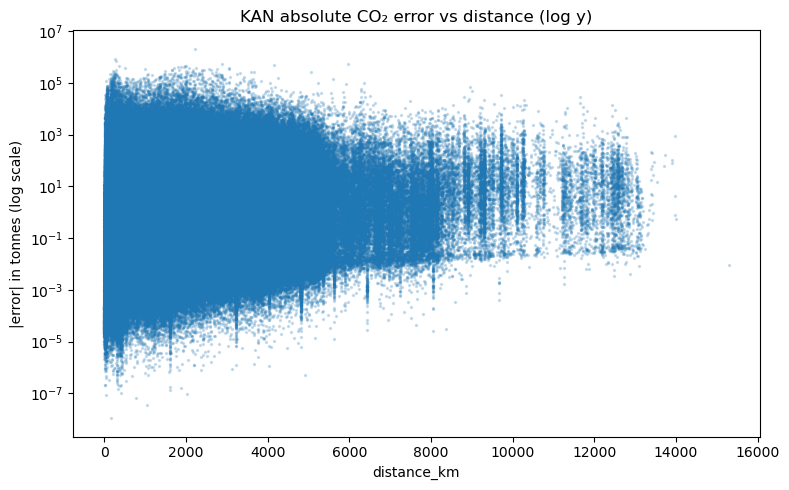

In [63]:
import matplotlib.pyplot as plt

e = df_int.copy()
e["abs_err_co2_kan"] = (e["co2_pred_tonnes_kan"] - e["co2_tonnes"]).abs()

plt.figure(figsize=(8,5))
plt.scatter(e["distance_km"], e["abs_err_co2_kan"], s=2, alpha=0.2)
plt.yscale("log")
plt.title("KAN absolute CO₂ error vs distance (log y)")
plt.xlabel("distance_km")
plt.ylabel("|error| in tonnes (log scale)")
plt.tight_layout()
plt.show()


In [64]:
# ============================================================
# EXPORT ARTIFACTS
# ============================================================
import os, json, glob
from datetime import datetime
import pandas as pd

EXPORT_ROOT = globals().get("EXPORT_ROOT", "exports_faf5_2024_multiobjective")


timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
export_dir = os.path.join(EXPORT_ROOT, timestamp)
os.makedirs(export_dir, exist_ok=True)
print("📦 Exporting to:", export_dir)


def ensure_row_id(frame: pd.DataFrame, name: str) -> pd.DataFrame:

    if frame is None:
        return None
    if "row_id" not in frame.columns:
        frame = frame.reset_index(drop=True).copy()
        frame["row_id"] = frame.index.astype("int64")
        print(f"✅ Added row_id to {name}")
    else:
        # normalize dtype (helps Parquet + ArcGIS joins)
        frame["row_id"] = pd.to_numeric(frame["row_id"], errors="coerce").astype("int64")
        print(f"✔ row_id already present in {name}")
    return frame

def safe_to_parquet(frame: pd.DataFrame, path: str, name: str):

    try:
        frame.to_parquet(path, index=False)
        print(f"✅ Wrote {name}: {os.path.basename(path)}  shape={frame.shape}")
    except Exception as e:
        csv_path = path.replace(".parquet", ".csv")
        frame.to_csv(csv_path, index=False)
        print(f"⚠ Parquet failed for {name} ({e}). Wrote CSV instead: {os.path.basename(csv_path)}  shape={frame.shape}")

# ---------- required objects ----------
if "df_int" not in globals():
    raise NameError("df_int not found. Run your pipeline until df_int exists (with preds) before exporting.")


df_int = ensure_row_id(df_int, "df_int")

if "df" in globals() and isinstance(df, pd.DataFrame):
    df = ensure_row_id(df, "df")
else:
    df = df_int.copy()
    df = ensure_row_id(df, "df (constructed from df_int)")
    print("⚠ `df` not found. Using df_int as df_full replacement.")


if "flows" in globals() and isinstance(flows, pd.DataFrame):
    flows = flows.copy()
else:
    flows = None


cfg = globals().get("cfg", {})
if not isinstance(cfg, dict):
    cfg = {}


pred_cols_expected = [
    "cost_pred", "co2_pred_tonnes", "gen_cost_pred",
    "cost_pred_kan", "co2_pred_tonnes_kan"
]
missing_preds_int = [c for c in pred_cols_expected if c not in df_int.columns]
missing_preds_full = [c for c in pred_cols_expected if c not in df.columns]
if missing_preds_int:
    print("⚠ df_int missing prediction cols:", missing_preds_int)
if missing_preds_full:
    print("⚠ df_full missing prediction cols:", missing_preds_full)

# ---------- write artifacts ----------
safe_to_parquet(df_int, os.path.join(export_dir, "df_int_with_preds.parquet"), "df_int_with_preds")
safe_to_parquet(df,     os.path.join(export_dir, "df_full_with_preds.parquet"), "df_full_with_preds")

if flows is not None:

    if "flow_id" not in flows.columns:
        flows = flows.reset_index(drop=True).copy()
        flows["flow_id"] = flows.index.astype("int64")
    safe_to_parquet(flows, os.path.join(export_dir, "flows_agg_rf_kan.parquet"), "flows_agg_rf_kan")
else:
    print("ℹ No `flows` found — skipping flows export.")

# ---------- write config ----------
cfg_out = cfg.copy()
cfg_out["export_dir"] = export_dir
cfg_out["export_timestamp"] = timestamp
cfg_out["df_int_shape"] = list(df_int.shape)
cfg_out["df_full_shape"] = list(df.shape)

with open(os.path.join(export_dir, "config.json"), "w", encoding="utf-8") as f:
    json.dump(cfg_out, f, indent=2)
print("✅ Wrote config.json")

print("\nDONE ✅")
print("Export folder:", export_dir)


📦 Exporting to: exports_faf5_2024_multiobjective\20260430_204028
✔ row_id already present in df_int
✔ row_id already present in df
✅ Wrote df_int_with_preds: df_int_with_preds.parquet  shape=(1678541, 45)
✅ Wrote df_full_with_preds: df_full_with_preds.parquet  shape=(1678541, 39)
✅ Wrote flows_agg_rf_kan: flows_agg_rf_kan.parquet  shape=(54684, 12)
✅ Wrote config.json

DONE ✅
Export folder: exports_faf5_2024_multiobjective\20260430_204028


## 11. Aggregate for OD Flow Mapping 





In [66]:
# === 11. Aggregate for OD Flow Mapping (RF + KAN, using df_int) ===


if "mode_pred" not in df_int.columns:
    df_int = df_int.join(df["mode_pred"], how="left")

flows = (
    df_int
      .groupby(["dms_orig", "dms_dest", "mode_pred"])
      .agg({
          "tons": "sum",
          "distance_km": "mean",

          # RF-based totals
          "cost_pred": "sum",
          "co2_pred_tonnes": "sum",
          "gen_cost_pred": "sum",

          # KAN-based totals
          "cost_pred_kan": "sum",
          "co2_pred_tonnes_kan": "sum",
          "gen_cost_pred_kan": "sum",
      })
      .reset_index()
)

flows = flows.rename(columns={
    "cost_pred": "cost_pred_rf_sum",
    "co2_pred_tonnes": "co2_pred_tonnes_rf_sum",
    "gen_cost_pred": "gen_cost_pred_rf_sum",
    "cost_pred_kan": "cost_pred_kan_sum",
    "co2_pred_tonnes_kan": "co2_pred_tonnes_kan_sum",
    "gen_cost_pred_kan": "gen_cost_pred_kan_sum",
})

flows_file = "FAF5_2024_flows_agg_multiobjective_with_KAN_intensity_pipeline.csv"
flows.to_csv(flows_file, index=False)

print("Aggregated OD flows (RF + KAN) saved to:", flows_file)
flows.head()


Aggregated OD flows (RF + KAN) saved to: FAF5_2024_flows_agg_multiobjective_with_KAN_intensity_pipeline.csv


,dms_orig,dms_dest,mode_pred,tons,distance_km,cost_pred_rf_sum,co2_pred_tonnes_rf_sum,gen_cost_pred_rf_sum,cost_pred_kan_sum,co2_pred_tonnes_kan_sum,gen_cost_pred_kan_sum
0,11,11,multi,9.006198e+03,83.675114,8.834136e+04,36.845490,9.202591e+04,3.603490e+05,93.279343,3.696770e+05
1,11,11,truck,3.748248e+07,57.158165,2.494458e+08,159855.687500,2.654314e+08,1.717918e+08,130569.937500,1.848488e+08
2,11,12,air,4.400000e-02,494.935913,4.317992e+01,0.008343,4.401421e+01,5.303062e+01,0.010149,5.404553e+01
3,11,12,multi,1.248308e+03,449.573398,9.401298e+04,34.443344,9.745732e+04,2.466616e+05,67.627541,2.534243e+05
4,11,12,truck,4.735855e+06,467.107063,2.428905e+08,124663.859375,2.553569e+08,5.479480e+08,209964.593750,5.689444e+08


## 12. Data Visualizations & Model Evaluation

### 12.0 Setup 

In [69]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.ensemble import RandomForestRegressor



OUTPUT_DIR = "model_evaluation_figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save_current_fig(name, dpi=300):

    
    path = os.path.join(OUTPUT_DIR, name)
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure to: {path}")


### 12.1 Consolidated Evaluation Metrics and Figures

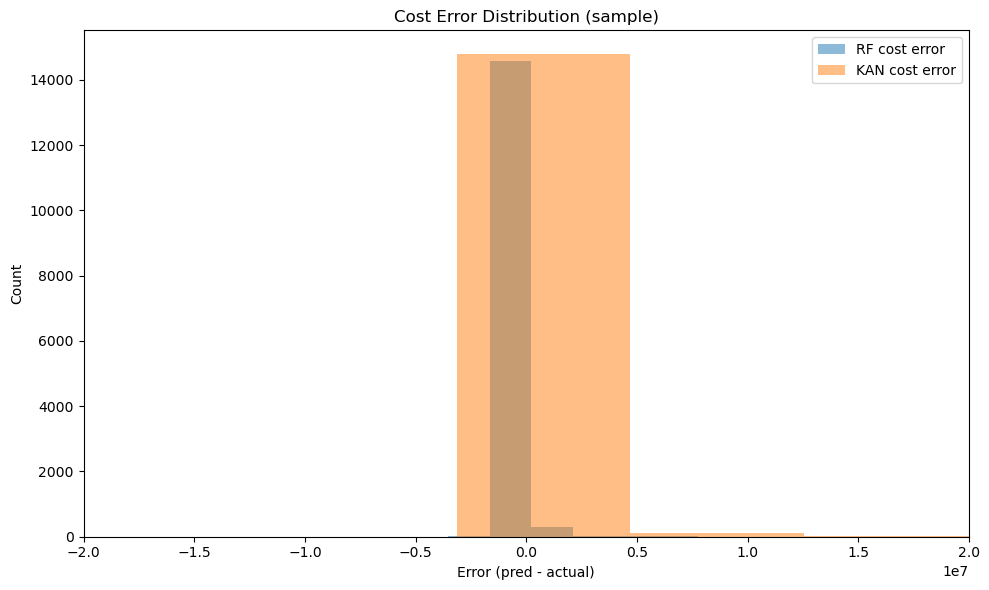

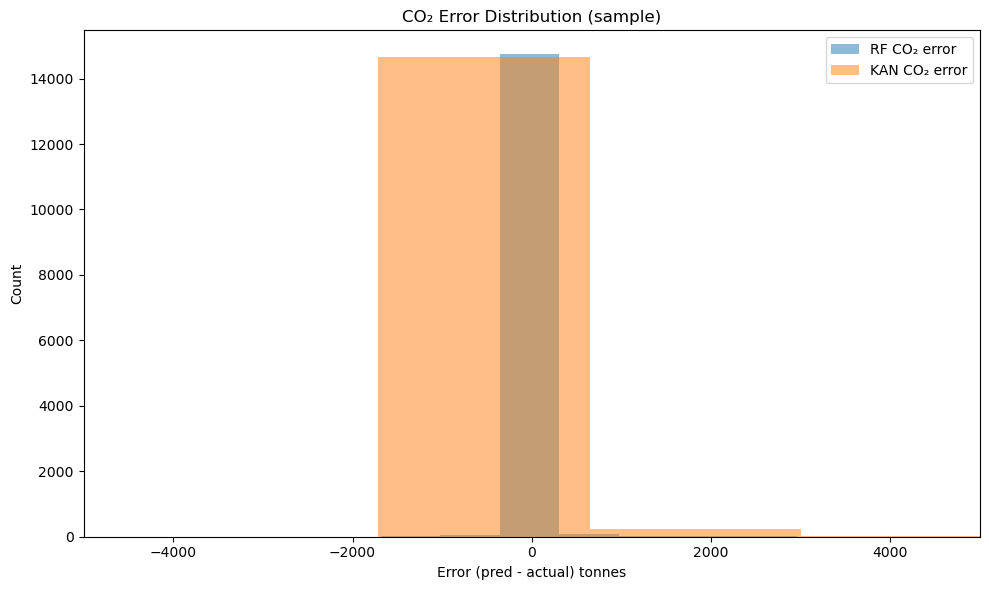

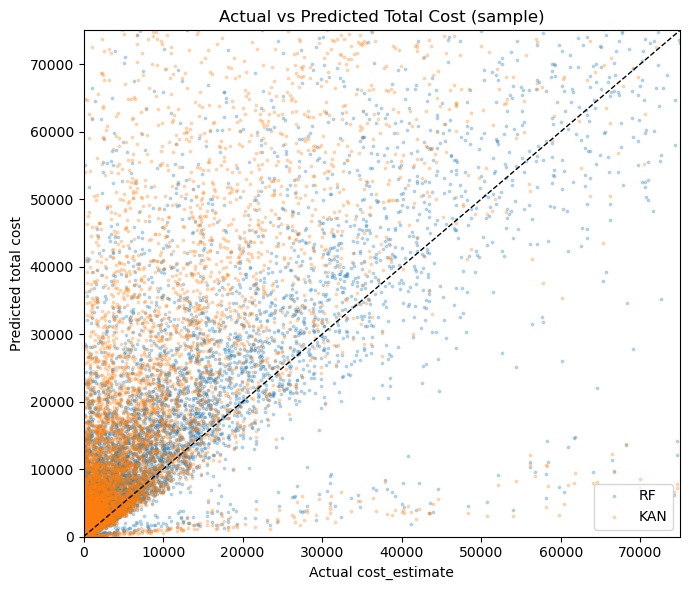

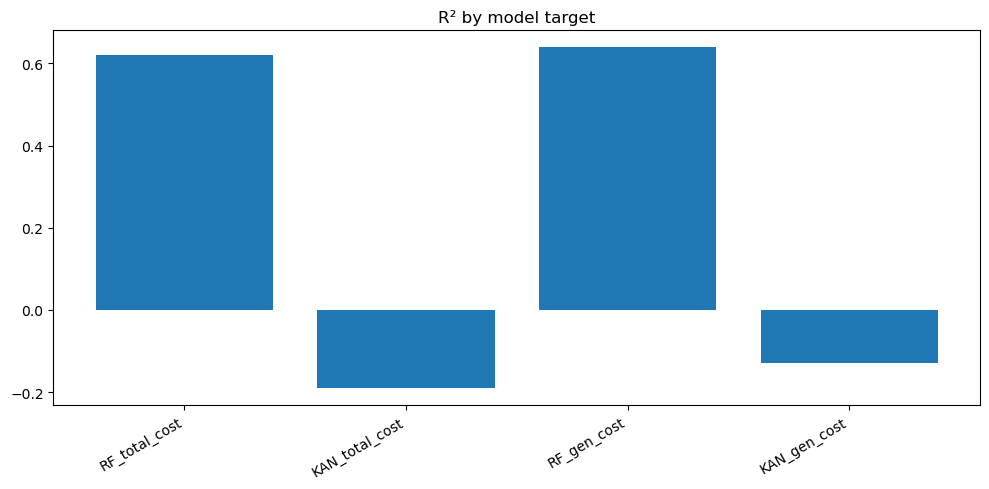

✔ Saved metrics: model_evaluation_figures\model_metrics_summary.csv
✔ Saved figures to: model_evaluation_figures


,MAE,RMSE,R2
RF_total_cost,113155.167557,4.819153e+06,0.619305
KAN_total_cost,472856.142651,8.521410e+06,-0.190306
RF_total_co2,52.291294,1.723311e+03,0.856804
KAN_total_co2,140.420924,3.356801e+03,0.456680
RF_gen_cost,116903.467231,4.957354e+06,0.638801
KAN_gen_cost,485567.776773,8.765906e+06,-0.129380


In [132]:
# ============================================================
# CONSOLIDATED EVALUATION (RF + KAN) + FIGURE EXPORTS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import root_mean_squared_error as rmse 

def evaluate_models(
    df_int: pd.DataFrame,
    *,
    
    ton_km_col="ton_km",
    cost_true_col="cost_estimate",
    co2_true_col="co2_tonnes",
    
    rf_cost_int_col="cost_per_tkm_pred_rf",
    rf_co2_int_col="co2_kg_per_tkm_pred_rf",
    
    kan_cost_int_col="cost_per_tkm_pred_kan",
    kan_co2_int_col="co2_kg_per_tkm_pred_kan",
    
    rf_cost_tot_col="cost_pred",
    rf_co2_tot_col="co2_pred_tonnes",
    kan_cost_tot_col="cost_pred_kan",
    kan_co2_tot_col="co2_pred_tonnes_kan",
    
    LAMBDA_CO2=100.0,
    rf_gen_col="gen_cost_pred",
    kan_gen_col="gen_cost_pred_kan",
    
    output_dir="model_evaluation_figures",
    sample_scatter=15000,
    random_state=42,
    save_figs=True,
):
    df_int = df_int.copy()

    os.makedirs(output_dir, exist_ok=True)

    # --- checks ---
    required = [ton_km_col, cost_true_col, co2_true_col]
    missing = [c for c in required if c not in df_int.columns]
    if missing:
        raise KeyError(f"df_int missing required columns: {missing}")

    # --- rebuild RF totals if missing ---
    if rf_cost_tot_col not in df_int.columns:
        if rf_cost_int_col not in df_int.columns:
            raise KeyError(f"Missing RF intensity column: {rf_cost_int_col}")
        df_int[rf_cost_tot_col] = df_int[rf_cost_int_col].astype("float32") * df_int[ton_km_col].astype("float32")

    if rf_co2_tot_col not in df_int.columns:
        if rf_co2_int_col not in df_int.columns:
            raise KeyError(f"Missing RF CO2 intensity column: {rf_co2_int_col}")
        df_int[rf_co2_tot_col] = (df_int[rf_co2_int_col].astype("float32") * df_int[ton_km_col].astype("float32")) / 1000.0

    # --- rebuild KAN totals if missing ---
    if kan_cost_tot_col not in df_int.columns:
        if kan_cost_int_col not in df_int.columns:
            raise KeyError(f"Missing KAN intensity column: {kan_cost_int_col}")
        df_int[kan_cost_tot_col] = df_int[kan_cost_int_col].astype("float32") * df_int[ton_km_col].astype("float32")

    if kan_co2_tot_col not in df_int.columns:
     
        if kan_co2_int_col not in df_int.columns:
            raise KeyError(f"Missing KAN CO2 intensity column: {kan_co2_int_col}")
        df_int[kan_co2_tot_col] = (df_int[kan_co2_int_col].astype("float32") * df_int[ton_km_col].astype("float32")) / 1000.0

    # --- generalized cost ---
    df_int[rf_gen_col]  = df_int[rf_cost_tot_col]  + float(LAMBDA_CO2) * df_int[rf_co2_tot_col]
    df_int[kan_gen_col] = df_int[kan_cost_tot_col] + float(LAMBDA_CO2) * df_int[kan_co2_tot_col]

    # --- errors  ---
    df_int["cost_error"] = df_int[rf_cost_tot_col] - df_int[cost_true_col]
    df_int["cost_error_kan"] = df_int[kan_cost_tot_col] - df_int[cost_true_col]
    df_int["co2_error_tonnes"] = df_int[rf_co2_tot_col] - df_int[co2_true_col]
    df_int["co2_error_tonnes_kan"] = df_int[kan_co2_tot_col] - df_int[co2_true_col]
    df_int["gen_cost_error"] = df_int[rf_gen_col] - (df_int[cost_true_col] + float(LAMBDA_CO2)*df_int[co2_true_col])
    df_int["gen_cost_error_kan"] = df_int[kan_gen_col] - (df_int[cost_true_col] + float(LAMBDA_CO2)*df_int[co2_true_col])

    # --- metrics table ---
    metrics = {
        "RF_total_cost": {
            "MAE": mean_absolute_error(df_int[cost_true_col], df_int[rf_cost_tot_col]),
            "RMSE": rmse(df_int[cost_true_col], df_int[rf_cost_tot_col]),
            "R2": r2_score(df_int[cost_true_col], df_int[rf_cost_tot_col]),
        },
        "KAN_total_cost": {
            "MAE": mean_absolute_error(df_int[cost_true_col], df_int[kan_cost_tot_col]),
            "RMSE": rmse(df_int[cost_true_col], df_int[kan_cost_tot_col]),
            "R2": r2_score(df_int[cost_true_col], df_int[kan_cost_tot_col]),
        },
        "RF_total_co2": {
            "MAE": mean_absolute_error(df_int[co2_true_col], df_int[rf_co2_tot_col]),
            "RMSE": rmse(df_int[co2_true_col], df_int[rf_co2_tot_col]),
            "R2": r2_score(df_int[co2_true_col], df_int[rf_co2_tot_col]),
        },
        "KAN_total_co2": {
            "MAE": mean_absolute_error(df_int[co2_true_col], df_int[kan_co2_tot_col]),
            "RMSE": rmse(df_int[co2_true_col], df_int[kan_co2_tot_col]),
            "R2": r2_score(df_int[co2_true_col], df_int[kan_co2_tot_col]),
        },
        "RF_gen_cost": {
            "MAE": mean_absolute_error(
                df_int[cost_true_col] + float(LAMBDA_CO2)*df_int[co2_true_col],
                df_int[rf_gen_col]
            ),
            "RMSE": rmse(
                df_int[cost_true_col] + float(LAMBDA_CO2)*df_int[co2_true_col],
                df_int[rf_gen_col]
            ),
            "R2": r2_score(
                df_int[cost_true_col] + float(LAMBDA_CO2)*df_int[co2_true_col],
                df_int[rf_gen_col]
            ),
        },
        "KAN_gen_cost": {
            "MAE": mean_absolute_error(
                df_int[cost_true_col] + float(LAMBDA_CO2)*df_int[co2_true_col],
                df_int[kan_gen_col]
            ),
            "RMSE": rmse(
                df_int[cost_true_col] + float(LAMBDA_CO2)*df_int[co2_true_col],
                df_int[kan_gen_col]
            ),
            "R2": r2_score(
                df_int[cost_true_col] + float(LAMBDA_CO2)*df_int[co2_true_col],
                df_int[kan_gen_col]
            ),
        },
    }
    metrics_df = pd.DataFrame(metrics).T

    
    # --- figures  ---
    if save_figs:
        n = min(sample_scatter, len(df_int))
        samp = df_int.sample(n, random_state=random_state) if n < len(df_int) else df_int

        # 1) Error histograms (cost + CO2)
        plt.figure(figsize=(10,6))
        plt.hist(samp["cost_error"].dropna(), bins=80, alpha=0.5, label="RF cost error")
        plt.hist(samp["cost_error_kan"].dropna(), bins=80, alpha=0.5, label="KAN cost error")
        plt.title("Cost Error Distribution (sample)")
        plt.xlabel("Error (pred - actual)")
        plt.ylabel("Count")
        plt.legend()
        plt.xlim(-20000000,20000000)
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "cost_error_hist.png"), dpi=250)
        plt.show()

        plt.figure(figsize=(10,6))
        plt.hist(samp["co2_error_tonnes"].dropna(), bins=80, alpha=0.5, label="RF CO₂ error")
        plt.hist(samp["co2_error_tonnes_kan"].dropna(), bins=80, alpha=0.5, label="KAN CO₂ error")
        plt.title("CO₂ Error Distribution (sample)")
        plt.xlabel("Error (pred - actual) tonnes")
        plt.ylabel("Count")
        plt.legend()
        plt.xlim(-5000,5000)
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "co2_error_hist.png"), dpi=250)
        plt.show()

        # 2) Actual vs Pred scatter (cost totals)
        max_cost = float(samp[cost_true_col].max())
        plt.figure(figsize=(7,6))
        plt.scatter(samp[cost_true_col], samp[rf_cost_tot_col], s=3, alpha=0.25, label="RF")
        plt.scatter(samp[cost_true_col], samp[kan_cost_tot_col], s=3, alpha=0.25, label="KAN")
        plt.plot([0, 75000], [0, 75000], "k--", linewidth=1)
        plt.title("Actual vs Predicted Total Cost (sample)")
        plt.xlabel("Actual cost_estimate")
        plt.ylabel("Predicted total cost")
        plt.legend()
        plt.ylim(0,75000)
        plt.xlim(0,75000)
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "actual_vs_pred_total_cost.png"), dpi=250)
        plt.show()

       
        # 3) Metrics bar chart (MAE/RMSE/R2)
        plot_df = metrics_df.loc[
            ["RF_total_cost","KAN_total_cost","RF_gen_cost","KAN_gen_cost"],
            ["MAE","RMSE","R2"]
        ].copy()

        plt.figure(figsize=(10,5))
        plt.bar(plot_df.index, plot_df["R2"].values)
        plt.title("R² by model target")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "r2_bar.png"), dpi=250)
        plt.show()

    # save metrics CSV
    metrics_path = os.path.join(output_dir, "model_metrics_summary.csv")
    metrics_df.to_csv(metrics_path, index=True)
    print("✔ Saved metrics:", metrics_path)
    print("✔ Saved figures to:", output_dir)

    return df_int, metrics_df



df_int_eval, metrics_df = evaluate_models(
    df_int,
    LAMBDA_CO2=LAMBDA_CO2 if "LAMBDA_CO2" in globals() else 100.0,
    save_figs=True
)

display(metrics_df)


### 12.2 KAN vs RF Comparison Table

In [73]:
# ======================================
# KAN vs RF COMPARISON TABLE (REPORT)
# ======================================

comparison = metrics_df.copy()


order = [
    "RF_total_cost", "KAN_total_cost",
    "RF_total_co2",  "KAN_total_co2",
    "RF_gen_cost",   "KAN_gen_cost"
]
comparison = comparison.loc[order, ["MAE","RMSE","R2"]]


comparison.index = [
    "RF – Total Cost",
    "KAN – Total Cost",
    "RF – Total CO₂",
    "KAN – Total CO₂",
    "RF – Generalized Cost",
    "KAN – Generalized Cost",
]


comparison_rounded = comparison.copy()
comparison_rounded["MAE"]  = comparison_rounded["MAE"].astype(float).round(4)
comparison_rounded["RMSE"] = comparison_rounded["RMSE"].astype(float).round(4)
comparison_rounded["R2"]   = comparison_rounded["R2"].astype(float).round(4)

display(comparison_rounded)

# Save
out_dir = "model_evaluation_figures"
os.makedirs(out_dir, exist_ok=True)
comparison_rounded.to_csv(os.path.join(out_dir, "kan_vs_rf_comparison_table.csv"), index=True)
print("✔ Saved:", os.path.join(out_dir, "kan_vs_rf_comparison_table.csv"))


,MAE,RMSE,R2
RF – Total Cost,113155.1676,4.819153e+06,0.6193
KAN – Total Cost,472856.1427,8.521410e+06,-0.1903
RF – Total CO₂,52.2913,1.723311e+03,0.8568
KAN – Total CO₂,140.4209,3.356801e+03,0.4567
RF – Generalized Cost,116903.4672,4.957354e+06,0.6388
KAN – Generalized Cost,485567.7768,8.765906e+06,-0.1294


✔ Saved: model_evaluation_figures\kan_vs_rf_comparison_table.csv


### 12.3 KAN Surrogate Feature Importance (RF on KAN predictions)

Possible target columns: ['cost_per_tkm_pred_rf', 'cost_pred', 'gen_cost_pred', 'cost_per_tkm_pred_kan', 'cost_pred_kan', 'gen_cost_pred_kan', 'cost_error_kan', 'gen_cost_error_kan']
Note: name count (8) != importance count (7). Using original feature labels.
Saved figure to: model_evaluation_figures\kan_surrogate_feature_importance.png


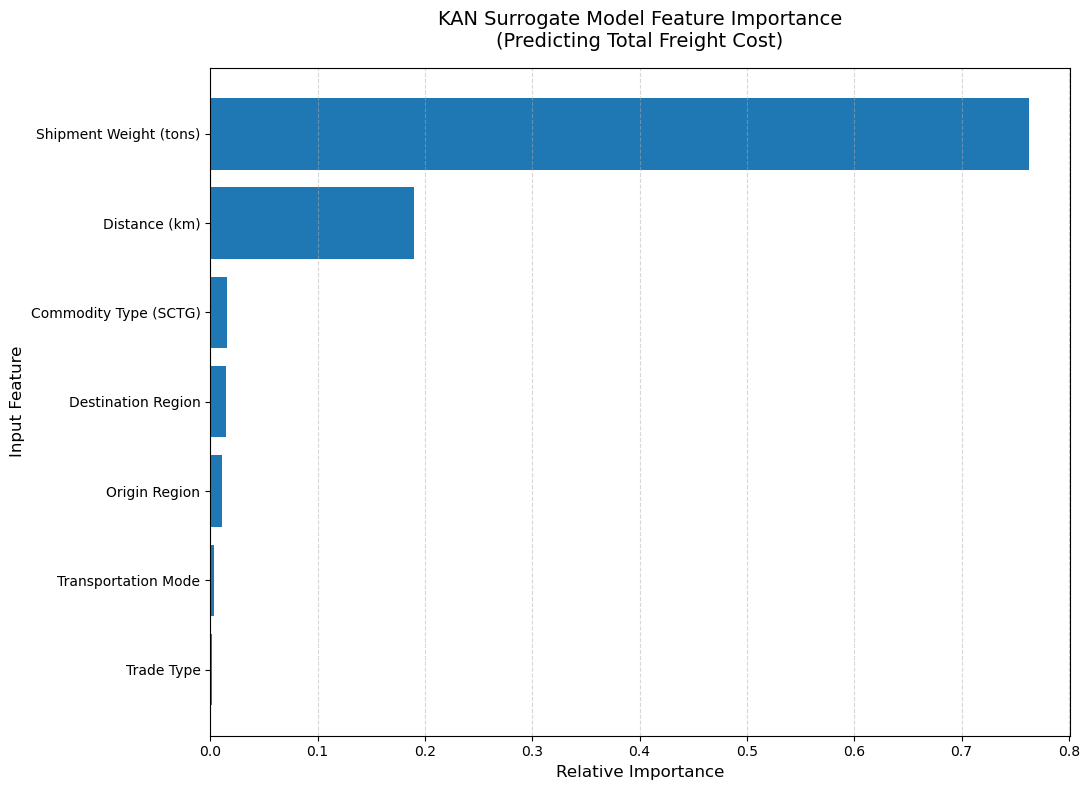

In [83]:
# === KAN Surrogate Feature Importance (Cost) ===

target_candidates = [c for c in df_int.columns if ("pred" in c.lower() and "cost" in c.lower()) or ("kan" in c.lower() and "cost" in c.lower())]
print("Possible target columns:", target_candidates)

if "cost_pred_kan" not in df_int.columns:
    raise KeyError(f"'cost_pred_kan' not found. Candidates: {target_candidates}")

feature_cols_int = [
    "distance_km",
    "tons",
    "sctg2",
    "dms_orig",
    "dms_dest",
    "trade_type",
    "mode_pred",
    "dist_band",
]

X_sur_raw = df_int[feature_cols_int].copy()
y_sur = df_int["cost_pred_kan"].astype("float32")

preprocess_reg = reg_cost_int.named_steps["preprocess"]
X_sur_proc = preprocess_reg.transform(X_sur_raw)

surrogate = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
surrogate.fit(X_sur_proc, y_sur)
importances = surrogate.feature_importances_


pretty_feature_map = {
    "distance_km": "Distance (km)",
    "tons": "Shipment Weight (tons)",
    "sctg2": "Commodity Type (SCTG)",
    "dms_orig": "Origin Region",
    "dms_dest": "Destination Region",
    "trade_type": "Trade Type",
    "mode_pred": "Transportation Mode",
    "dist_band": "Distance Band",
}

def _build_feature_names_from_column_transformer(ct, raw_cols):

    names = []
    for name, trans, cols in ct.transformers_:
        if trans == "drop":
            continue

        
        if cols is None:
            cols_list = []
        elif isinstance(cols, (list, tuple, np.ndarray)):
            cols_list = list(cols)
        else:
            cols_list = [cols]

        
        cols_list = [raw_cols[c] if isinstance(c, (int, np.integer)) else c for c in cols_list]

        
        if hasattr(trans, "steps"):
            trans_final = trans.steps[-1][1]
        else:
            trans_final = trans

        
        if trans == "passthrough" or trans_final == "passthrough":
            names.extend(cols_list)
            continue

        s
        if hasattr(trans_final, "get_feature_names_out"):
            try:
                out = trans_final.get_feature_names_out(cols_list)
                names.extend(list(out))
                continue
            except Exception:
                pass

        
        names.extend(cols_list)

    return np.array(names)

# --- Get feature names ---
try:
    feature_names_expanded = _build_feature_names_from_column_transformer(preprocess_reg, feature_cols_int)
except Exception:
    feature_names_expanded = np.array(feature_cols_int)


if len(feature_names_expanded) != len(importances):
    print(f"Note: name count ({len(feature_names_expanded)}) != importance count ({len(importances)}). Using original feature labels.")
    feature_names_expanded = np.array(feature_cols_int[: len(importances)])

# Label Converter
clean_names = []
for n in feature_names_expanded:
    base = str(n)
   
    base_col = base.split("_")[0] if base.split("_")[0] in pretty_feature_map else base
    nice = pretty_feature_map.get(base_col, base_col)
    # Keep suffix if present
    if base != base_col:
        suffix = base[len(base_col):].lstrip("_")
        clean_names.append(f"{nice}: {suffix}")
    else:
        clean_names.append(nice)

clean_names = np.array(clean_names)

# --- Plot ---
plt.figure(figsize=(11, 8))
idx = np.argsort(importances)
plt.barh(clean_names[idx], importances[idx])
plt.title("KAN Surrogate Model Feature Importance\n(Predicting Total Freight Cost)", fontsize=14, pad=15)
plt.xlabel("Relative Importance", fontsize=12)
plt.ylabel("Input Feature", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()

save_current_fig("kan_surrogate_feature_importance.png")
plt.show()


### 12.4 Mode Prediction Confusion Matrix

Saved figure to: model_evaluation_figures\mode_confusion_matrix.png


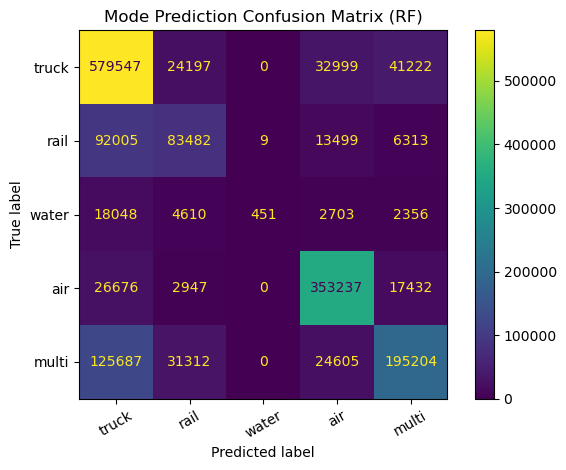

In [85]:



labels = ["truck", "rail", "water", "air", "multi"]


y_true = df["mode_name"].astype(str)
y_pred = df["mode_pred"].astype(str)

cm = confusion_matrix(y_true, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d", xticks_rotation=30)
plt.title("Mode Prediction Confusion Matrix (RF)")
plt.tight_layout()
save_current_fig("mode_confusion_matrix.png")
plt.show()



### 12.5 Error vs Distance (Systematic Bias)

C:\Users\id145\AppData\Local\Temp\ipykernel_8188\308825500.py:24: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(path, dpi=dpi, bbox_inches="tight")


Saved figure to: model_evaluation_figures\cost_error_vs_distance.png


C:\Users\id145\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


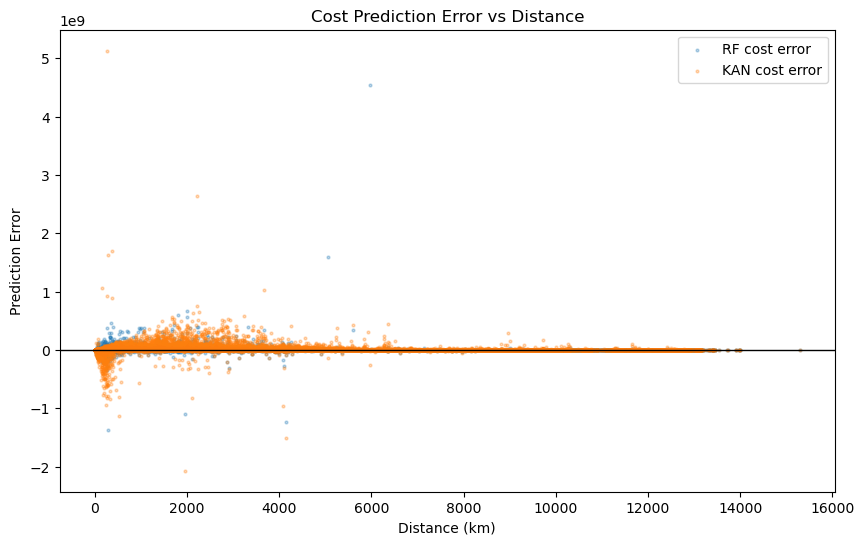

In [87]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df_int["distance_km"],
    df_int["cost_error"],
    s=4,
    alpha=0.3,
    label="RF cost error",
)
plt.scatter(
    df_int["distance_km"],
    df_int["cost_error_kan"],
    s=4,
    alpha=0.3,
    label="KAN cost error",
)
plt.axhline(0, color="black", linewidth=1)

plt.title("Cost Prediction Error vs Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Prediction Error")
plt.legend()

save_current_fig("cost_error_vs_distance.png")
plt.show()


### 12.6 Carbon Price Sensitivity (λ vs Mean Generalized Cost by Mode)




Carbon price sensitivity rows: 60
Saved figure to: model_evaluation_figures\carbon_price_sensitivity_by_mode_baseline_vs_kan.png


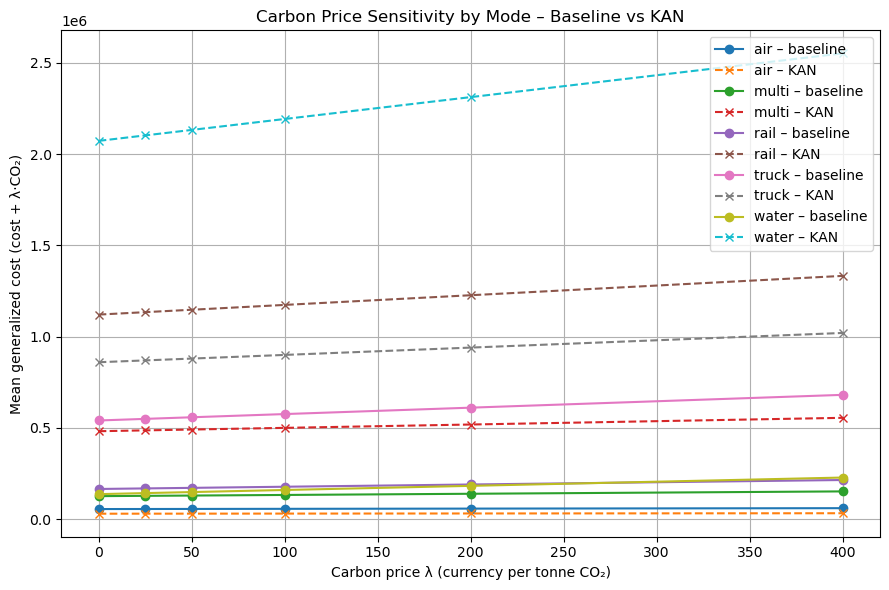

In [89]:
lambdas = [0, 25, 50, 100, 200, 400]
mode_list = sorted(df_int["mode_name"].unique())

rows = []

for lam in lambdas:
    gen_base = df_int["cost_estimate"] + lam * df_int["co2_tonnes"]
    gen_kan  = df_int["cost_pred_kan"] + lam * df_int["co2_pred_tonnes_kan"]

    for m in mode_list:
        mask = df_int["mode_name"] == m
        if not mask.any():
            continue

        rows.append({
            "lambda": lam,
            "mode_name": m,
            "model_type": "Baseline",
            "mean_gen_cost": gen_base[mask].mean(),
        })

        rows.append({
            "lambda": lam,
            "mode_name": m,
            "model_type": "KAN",
            "mean_gen_cost": gen_kan[mask].mean(),
        })

sens_df = pd.DataFrame(rows)
print("Carbon price sensitivity rows:", len(sens_df))
sens_df.head()

plt.figure(figsize=(9, 6))

for m in mode_list:
    sub_base = sens_df[(sens_df["mode_name"] == m) & (sens_df["model_type"] == "Baseline")]
    sub_kan  = sens_df[(sens_df["mode_name"] == m) & (sens_df["model_type"] == "KAN")]

    if not sub_base.empty:
        plt.plot(sub_base["lambda"], sub_base["mean_gen_cost"],
                 marker="o", linestyle="-", label=f"{m} – baseline")

    if not sub_kan.empty:
        plt.plot(sub_kan["lambda"], sub_kan["mean_gen_cost"],
                 marker="x", linestyle="--", label=f"{m} – KAN")

plt.xlabel("Carbon price λ (currency per tonne CO₂)")
plt.ylabel("Mean generalized cost (cost + λ·CO₂)")
plt.title("Carbon Price Sensitivity by Mode – Baseline vs KAN")
plt.legend()
plt.grid(True)
plt.tight_layout()
save_current_fig("carbon_price_sensitivity_by_mode_baseline_vs_kan.png")
plt.show()


Saved figure to: model_evaluation_figures\pareto_cost_vs_co2_baseline_vs_kan.png


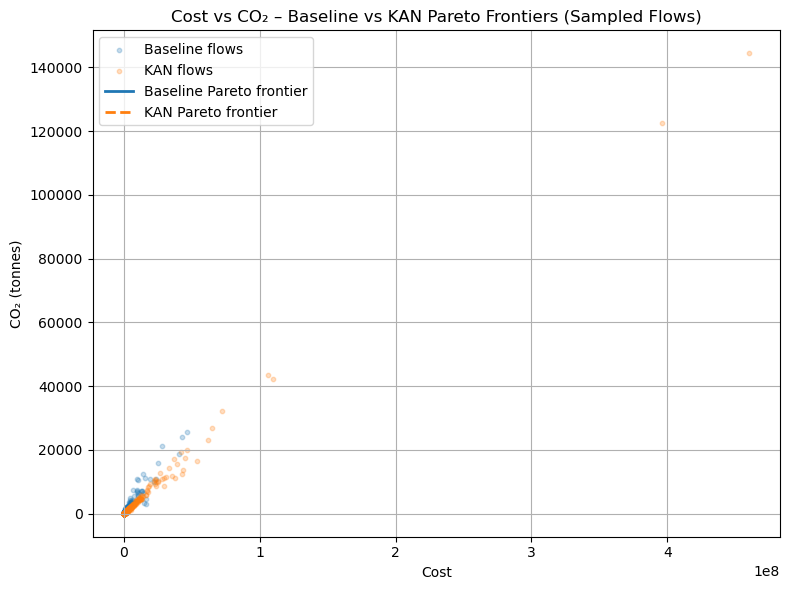

(   cost_estimate  co2_tonnes
 0       0.180578    0.000099,
    cost_kan   co2_kan
 0  0.334862  0.000124)

In [90]:
sample_size = min(5000, len(df_int))
sample_idx = df_int.sample(sample_size, random_state=42).index

sample_base = df_int.loc[sample_idx, ["cost_estimate", "co2_tonnes"]].copy()
sample_kan = df_int.loc[sample_idx, ["cost_pred_kan", "co2_pred_tonnes_kan"]].copy()
sample_kan.columns = ["cost_kan", "co2_kan"]

# Baseline Pareto
sample_base_sorted = sample_base.sort_values("cost_estimate").reset_index(drop=True)
pareto_flags_base = np.zeros(len(sample_base_sorted), dtype=bool)
min_co2 = np.inf
for i in range(len(sample_base_sorted)):
    co2 = sample_base_sorted.loc[i, "co2_tonnes"]
    if co2 < min_co2:
        pareto_flags_base[i] = True
        min_co2 = co2
pareto_base = sample_base_sorted[pareto_flags_base]

# KAN Pareto
sample_kan_sorted = sample_kan.sort_values("cost_kan").reset_index(drop=True)
pareto_flags_kan = np.zeros(len(sample_kan_sorted), dtype=bool)
min_co2_kan = np.inf
for i in range(len(sample_kan_sorted)):
    co2 = sample_kan_sorted.loc[i, "co2_kan"]
    if co2 < min_co2_kan:
        pareto_flags_kan[i] = True
        min_co2_kan = co2
pareto_kan = sample_kan_sorted[pareto_flags_kan]

plt.figure(figsize=(8, 6))

plt.scatter(sample_base["cost_estimate"], sample_base["co2_tonnes"],
            alpha=0.25, label="Baseline flows", s=10)

plt.scatter(sample_kan["cost_kan"], sample_kan["co2_kan"],
            alpha=0.25, label="KAN flows", s=10)

plt.plot(pareto_base["cost_estimate"], pareto_base["co2_tonnes"],
         linewidth=2, label="Baseline Pareto frontier")

plt.plot(pareto_kan["cost_kan"], pareto_kan["co2_kan"],
         linewidth=2, linestyle="--", label="KAN Pareto frontier")

plt.xlabel("Cost")
plt.ylabel("CO₂ (tonnes)")
plt.title("Cost vs CO₂ – Baseline vs KAN Pareto Frontiers (Sampled Flows)")
plt.grid(True)
plt.legend()
plt.tight_layout()
save_current_fig("pareto_cost_vs_co2_baseline_vs_kan.png")
plt.show()

pareto_base.head(), pareto_kan.head()


In [134]:
import shutil
import os

shutil.make_archive("model_evaluation_figures", "zip", "model_evaluation_figures")

print("Created:", os.path.abspath("model_evaluation_figures.zip"))

Created: C:\Users\id145\model_evaluation_figures.zip


## Export Artifacts & Loader


In [93]:
# ============================================================
# EXPORT ARTIFACTS 
# ============================================================

import os, json, glob
from datetime import datetime
import pandas as pd

EXPORT_ROOT = globals().get("EXPORT_ROOT", "exports_faf5_2024_multiobjective")


timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
export_dir = os.path.join(EXPORT_ROOT, timestamp)
os.makedirs(export_dir, exist_ok=True)
print("📦 Exporting to:", export_dir)


def ensure_row_id(frame: pd.DataFrame, name: str) -> pd.DataFrame:

    if frame is None:
        return None
    if "row_id" not in frame.columns:
        frame = frame.reset_index(drop=True).copy()
        frame["row_id"] = frame.index.astype("int64")
        print(f"✅ Added row_id to {name}")
    else:
        # normalize dtype (helps Parquet + ArcGIS joins)
        frame["row_id"] = pd.to_numeric(frame["row_id"], errors="coerce").astype("int64")
        print(f"✔ row_id already present in {name}")
    return frame

def safe_to_parquet(frame: pd.DataFrame, path: str, name: str):

    try:
        frame.to_parquet(path, index=False)
        print(f"✅ Wrote {name}: {os.path.basename(path)}  shape={frame.shape}")
    except Exception as e:
        csv_path = path.replace(".parquet", ".csv")
        frame.to_csv(csv_path, index=False)
        print(f"⚠ Parquet failed for {name} ({e}). Wrote CSV instead: {os.path.basename(csv_path)}  shape={frame.shape}")


# ---------- required objects ----------
if "df_int" not in globals():
    raise NameError("df_int not found. Run your pipeline until df_int exists (with preds) before exporting.")


df_int = ensure_row_id(df_int, "df_int")

if "df" in globals() and isinstance(df, pd.DataFrame):
    df = ensure_row_id(df, "df")
else:
    df = df_int.copy()
    df = ensure_row_id(df, "df (constructed from df_int)")
    print("⚠ `df` not found. Using df_int as df_full replacement.")


if "flows" in globals() and isinstance(flows, pd.DataFrame):
    flows = flows.copy()
else:
    flows = None

# cfg optional
cfg = globals().get("cfg", {})
if not isinstance(cfg, dict):
    cfg = {}


pred_cols_expected = [
    "cost_pred", "co2_pred_tonnes", "gen_cost_pred",
    "cost_pred_kan", "co2_pred_tonnes_kan"
]
missing_preds_int = [c for c in pred_cols_expected if c not in df_int.columns]
missing_preds_full = [c for c in pred_cols_expected if c not in df.columns]
if missing_preds_int:
    print("⚠ df_int missing prediction cols:", missing_preds_int)
if missing_preds_full:
    print("⚠ df_full missing prediction cols:", missing_preds_full)

# ---------- write artifacts ----------
safe_to_parquet(df_int, os.path.join(export_dir, "df_int_with_preds.parquet"), "df_int_with_preds")
safe_to_parquet(df,     os.path.join(export_dir, "df_full_with_preds.parquet"), "df_full_with_preds")

if flows is not None:

    if "flow_id" not in flows.columns:
        flows = flows.reset_index(drop=True).copy()
        flows["flow_id"] = flows.index.astype("int64")
    safe_to_parquet(flows, os.path.join(export_dir, "flows_agg_rf_kan.parquet"), "flows_agg_rf_kan")
else:
    print("ℹ No `flows` found — skipping flows export.")

# ---------- write config ----------
cfg_out = cfg.copy()
cfg_out["export_dir"] = export_dir
cfg_out["export_timestamp"] = timestamp
cfg_out["df_int_shape"] = list(df_int.shape)
cfg_out["df_full_shape"] = list(df.shape)

with open(os.path.join(export_dir, "config.json"), "w", encoding="utf-8") as f:
    json.dump(cfg_out, f, indent=2)
print("✅ Wrote config.json")

print("\nDONE ✅")
print("Export folder:", export_dir)

📦 Exporting to: exports_faf5_2024_multiobjective\20260430_210414
✔ row_id already present in df_int
✔ row_id already present in df
✅ Wrote df_int_with_preds: df_int_with_preds.parquet  shape=(1678541, 45)
✅ Wrote df_full_with_preds: df_full_with_preds.parquet  shape=(1678541, 39)
✅ Wrote flows_agg_rf_kan: flows_agg_rf_kan.parquet  shape=(54684, 12)
✅ Wrote config.json

DONE ✅
Export folder: exports_faf5_2024_multiobjective\20260430_210414


In [94]:
# ================================
# LOAD ARTIFACTS (ROBUST)
# ================================
import os, glob, json
import pandas as pd
import joblib
import torch

EXPORT_ROOT = "exports_faf5_2024_multiobjective"

latest_dir = max(
    (d for d in glob.glob(os.path.join(EXPORT_ROOT, "*")) if os.path.isdir(d)),
    key=os.path.getmtime
)
print("📦 Loading from:", latest_dir)

# --- DataFrames ---
df_int = pd.read_parquet(os.path.join(latest_dir, "df_int_with_preds.parquet"))
print("✔ Loaded df_int:", df_int.shape)

df_full_path = os.path.join(latest_dir, "df_full_with_preds.parquet")
if os.path.exists(df_full_path):
    df = pd.read_parquet(df_full_path)
    print("✔ Loaded df_full:", df.shape)
else:
    print("⚠ df_full_with_preds.parquet missing — reconstructing from df_int")
    df = df_int.copy()

# --- Optional flows ---
flows_path = os.path.join(latest_dir, "flows_agg_rf_kan.parquet")
if os.path.exists(flows_path):
    flows = pd.read_parquet(flows_path)
    print("✔ Loaded flows:", flows.shape)

# --- Models ---
def try_load(path):
    return joblib.load(path) if os.path.exists(path) else None

clf_mode = try_load(os.path.join(latest_dir, "clf_mode.joblib"))
reg_cost_int = try_load(os.path.join(latest_dir, "reg_cost_int.joblib"))
reg_co2_int  = try_load(os.path.join(latest_dir, "reg_co2_int.joblib"))

# --- Config ---
cfg_path = os.path.join(latest_dir, "config.json")
with open(cfg_path, "r", encoding="utf-8") as f:
    cfg = json.load(f)

print("✔ row_id present:", "row_id" in df.columns)


📦 Loading from: exports_faf5_2024_multiobjective\20260430_210414
✔ Loaded df_int: (1678541, 45)
✔ Loaded df_full: (1678541, 39)
✔ Loaded flows: (54684, 12)
✔ row_id present: True
